# From least squares to neural networks, PINNs, FNOs and PINOs

## A two-hour, executable introduction for materials-science students

This notebook develops one idea at a time:

> **Choose what mathematical object will be represented, calculate its prediction, measure disagreement, and adjust its parameters.**

The represented object changes:

| Method | What is represented? |
|---|---|
| Ordinary least squares (OLS) | A function with a supplied basis and a few fitted coefficients |
| Neural network (NN) | A flexible function with adjustable parameters |
| Physics-informed neural network (PINN) | Usually one trial solution field for one problem |
| Fourier neural operator (FNO) | A map from one field to another field across a family of problems |
| Physics-informed neural operator (PINO) | An operator trained using data and information from the governing equation |

The notebook repeatedly distinguishes a **network approximation**, a **named constitutive equation**, and a **physical mechanism**. They are not the same object.

### Google Colab instructions

1. Upload this notebook to Google Colab.
2. Select **Runtime → Run all**.
3. A GPU is optional. Every example also runs on a CPU.
4. Run cells in order because later sections reuse definitions introduced earlier.

All substantial code cells have a markdown cell before them explaining the aim and a markdown cell after them explaining how to read the result.

## Vocabulary used throughout

- **Input:** a number or collection of numbers supplied to a model.
- **Feature:** an input quantity used by a model. Grain size and position are examples.
- **Label or target:** a known output paired with an input.
- **Prediction:** the output calculated by the current model.
- **Parameter:** an adjustable number inside a model.
- **Residual:** prediction minus observation, or the amount by which a prediction violates an equation.
- **Loss:** one scalar number constructed from selected residuals.
- **Optimizer:** an algorithm that changes parameters to reduce a loss.
- **Epoch:** one complete training pass through the current training set.
- **Training set:** observations used to update model parameters.
- **Validation set:** separate observations used to select architecture, regularization and stopping time.
- **Test set:** observations kept untouched until the modelling procedure has been selected.

A test set is no longer independent if it repeatedly influences modelling decisions.

## 0. Set up a reproducible Colab environment

The next cell imports only packages already provided by Google Colab. It fixes random seeds, selects a GPU when one is available, and defines two small utility functions. Fixing a seed makes this teaching calculation repeatable; it does not remove uncertainty from a real experiment.

In [1]:
# Import the packages used throughout the notebook.
import copy
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Use one seed so repeated runs give the same teaching example.
SEED = 714
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Seed every GPU as well when CUDA is available.
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Use a GPU when available; otherwise use the CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set a readable default figure size and font size.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.6),
    "font.size": 11,
})


# Convert a NumPy array to a PyTorch tensor on the selected device.
def to_tensor(array, requires_grad=False):
    return torch.tensor(
        array,
        dtype=torch.float32,
        device=device,
        requires_grad=requires_grad,
    )


# Calculate root-mean-square error in the original output units.
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


print("PyTorch version:", torch.__version__)
print("Device:", device)


PyTorch version: 2.11.0
Device: cpu


The printed device is only a computational choice. It does not change the mathematical models. The seed is used again when datasets and models are created so that the figures are reproducible.

## Part I — Ordinary Least Squares

## Construct One Grain-Size Dataset

A single synthetic dataset is used throughout the OLS and neural-network sections.

It contains two deliberately imbalanced parts:

- **10 observations from 1 to 10 nm:** a small inverse Hall–Petch branch.
- **500 observations from 10 to 500 nm:** the dominant ordinary Hall–Petch branch.

The ordinary Hall–Petch model is

$$
\sigma_y(d)=\sigma_0+k d^{-1/2}.
$$

The two branches meet continuously at $d=10$ nm. The strength therefore:

- increases from $d=1$ to $10$ nm;
- reaches a maximum at $d=10$ nm;
- decreases from $d=10$ to $500$ nm.

The 10 inverse Hall–Petch observations are retained in the common dataset and shown in every relevant plot. However, they are tagged as a small anomalous group and are not used to define the ordinary train–validation–test split or the OLS parameter estimate. This reflects the intended teaching situation: a dominant Hall–Petch dataset contains a very small group of observations that may initially be treated as scatter or anomalous behavior.


In [2]:
# Create one reproducible random-number generator.
rng = np.random.default_rng(SEED)


# Grain-size coordinates


# Ten geometrically spaced points in the inverse Hall–Petch regime.
# endpoint=False avoids duplicating d = 10 nm.
d_inverse_nm = np.geomspace(
    1.0,
    10.0,
    10,
    endpoint=False
)

# Five hundred geometrically spaced points in the ordinary
# Hall–Petch regime, including d = 10 nm.
d_hp_nm = np.geomspace(
    10.0,
    500.0,
    500
)

# Combine both branches into one common dataset.
d_nm = np.concatenate([
    d_inverse_nm,
    d_hp_nm
])

# Tags identify the two physical regimes.
inverse_mask = d_nm < 10.0
hp_mask = ~inverse_mask

inverse_idx = np.flatnonzero(inverse_mask)
hp_idx = np.flatnonzero(hp_mask)


# Ordinary Hall–Petch branch

sigma0_true = 155.0   # MPa
k_true = 430.0        # MPa nm^(1/2)

x_hp = d_nm**(-0.5)

# Classical Hall–Petch baseline over the complete grain-size range.
sigma_hp_baseline = sigma0_true + k_true * x_hp

# Strength at the branch junction, d = 10 nm.
d_transition = 10.0
sigma_transition = (
    sigma0_true
    + k_true / np.sqrt(d_transition)
)


# Inverse Hall–Petch branch


# Below 10 nm, strength decreases as grain size decreases.
# This positive power-law branch joins the ordinary branch
# continuously at d = 10 nm.
inverse_exponent = 0.55

sigma_inverse = sigma_transition * (
    d_nm / d_transition
)**inverse_exponent

# Select the appropriate branch for every observation.
sigma_true = np.where(
    inverse_mask,
    sigma_inverse,
    sigma_hp_baseline
)


# Measurement scatter


# Use modest scatter in the dominant Hall–Petch regime and
# slightly larger scatter for the 10 anomalous points.
noise_sd = np.where(
    inverse_mask,
    8.0,
    5.0
)

sigma_measured = sigma_true + rng.normal(
    loc=0.0,
    scale=noise_sd,
    size=d_nm.size
)


# Train-validation-test split


# Only the 500 ordinary Hall–Petch observations define the split.
# The 10 inverse Hall–Petch observations remain tagged anomalies.
shuffled_hp_idx = rng.permutation(hp_idx)

n_hp = len(shuffled_hp_idx)
n_train = int(0.60 * n_hp)
n_val = int(0.20 * n_hp)

train_idx = shuffled_hp_idx[:n_train]
val_idx = shuffled_hp_idx[n_train:n_train + n_val]
test_idx = shuffled_hp_idx[n_train + n_val:]

# Hall–Petch design matrix for every point.
X_all = np.column_stack([
    np.ones_like(x_hp),
    x_hp
])

print(f"Total observations              = {len(d_nm)}")
print(f"Inverse Hall–Petch anomalies    = {len(inverse_idx)}")
print(f"Ordinary Hall–Petch observations = {len(hp_idx)}")
print(
    "Training/validation/test sizes =",
    len(train_idx),
    len(val_idx),
    len(test_idx)
)


Total observations              = 510
Inverse Hall–Petch anomalies    = 10
Ordinary Hall–Petch observations = 500
Training/validation/test sizes = 300 100 100


The clean curve is known only because this is a synthetic teaching example. In an experiment, the true curve and branch labels would not be known in advance.

The ten points below 10 nm are intentionally rare. An analyst examining a dataset dominated by 500 ordinary Hall–Petch measurements could initially label these ten points as anomalous scatter. The later neural-network comparison asks whether a flexible model can represent the complete common dataset, including this small systematic group.


## Solve the OLS Problem

The supplied Hall–Petch model is linear in the transformed coordinate

$$
x=d^{-1/2},
$$

so that

$$
\sigma_y=\sigma_0+kx.
$$

For the ordinary Hall–Petch training observations,

$$
X=
\begin{bmatrix}
1 & d_1^{-1/2}\\
\vdots & \vdots\\
1 & d_N^{-1/2}
\end{bmatrix},
\qquad
\beta=
\begin{bmatrix}
\sigma_0\\
k
\end{bmatrix}.
$$

OLS estimates $\beta$ by minimizing

$$
\|X\beta-y\|_2^2.
$$

Only the dominant ordinary Hall–Petch training subset is used to estimate $\sigma_0$ and $k$. The fitted equation is nevertheless evaluated on all 510 observations, including the ten tagged anomaly points.


In [3]:
# Construct the training, validation, and test subsets.
X_train = X_all[train_idx]
y_train = sigma_measured[train_idx]

X_val = X_all[val_idx]
y_val = sigma_measured[val_idx]

X_test = X_all[test_idx]
y_test = sigma_measured[test_idx]

# Fit the ordinary Hall–Petch equation using the training subset.
beta_ols, *_ = np.linalg.lstsq(
    X_train,
    y_train,
    rcond=None
)

sigma0_ols, k_ols = beta_ols

# Evaluate the fitted equation for all 510 observations.
sigma_pred_ols = X_all @ beta_ols

# Report errors on the ordinary Hall–Petch split.
for name, idx in [
    ("training", train_idx),
    ("validation", val_idx),
    ("test", test_idx)
]:
    subset_rmse = rmse(
        sigma_measured[idx],
        sigma_pred_ols[idx]
    )

    print(
        f"{name:10s} RMSE = "
        f"{subset_rmse:6.2f} MPa"
    )

# Report the error for the ten excluded anomaly points separately.
anomaly_rmse = rmse(
    sigma_measured[inverse_idx],
    sigma_pred_ols[inverse_idx]
)

print(f"{'anomaly':10s} RMSE = {anomaly_rmse:6.2f} MPa")
print()
print(f"Generating sigma0 = {sigma0_true:.2f} MPa")
print(f"Recovered  sigma0 = {sigma0_ols:.2f} MPa")
print(f"Generating k      = {k_true:.2f} MPa nm^(1/2)")
print(f"Recovered  k      = {k_ols:.2f} MPa nm^(1/2)")


training   RMSE =   4.75 MPa
validation RMSE =   4.87 MPa
test       RMSE =   4.80 MPa
anomaly    RMSE = 303.01 MPa

Generating sigma0 = 155.00 MPa
Recovered  sigma0 = 155.20 MPa
Generating k      = 430.00 MPa nm^(1/2)
Recovered  k      = 429.57 MPa nm^(1/2)


The OLS fit is expected to recover $\sigma_0$ and $k$ accurately because it is trained on the 500-point ordinary Hall–Petch population.

The ten observations below 10 nm are not random noise in the synthetic ground truth; they form a genuine inverse Hall–Petch branch. However, they are deliberately treated as a small excluded anomaly group during the first-stage ordinary Hall–Petch analysis.

This distinction is important:

- OLS is not failing to solve its stated problem.
- The supplied two-parameter equation describes only the ordinary Hall–Petch regime.
- The small excluded group signals that the complete material response may contain another regime.


## Inspect the Dataset in Both Coordinates

Two horizontal coordinates are useful:

1. **$\sigma_y$ versus grain size $d$**, with a logarithmic $d$ axis.  
   This plot shows the physical grain-size range from 1 to 500 nm.

2. **$\sigma_y$ versus $d^{-1/2}$**, with a linear horizontal axis.  
   This is the conventional Hall–Petch plot, where the ordinary branch is a straight line.

The inverse Hall–Petch points occur at the smallest grain sizes. Therefore:

- they appear at the far **left** of the $\sigma_y$-versus-$d$ plot;
- they appear at the far **right** of the $\sigma_y$-versus-$d^{-1/2}$ plot.


In [4]:
# Residual = measured strength - OLS prediction
residuals_ols = sigma_measured - sigma_pred_ols


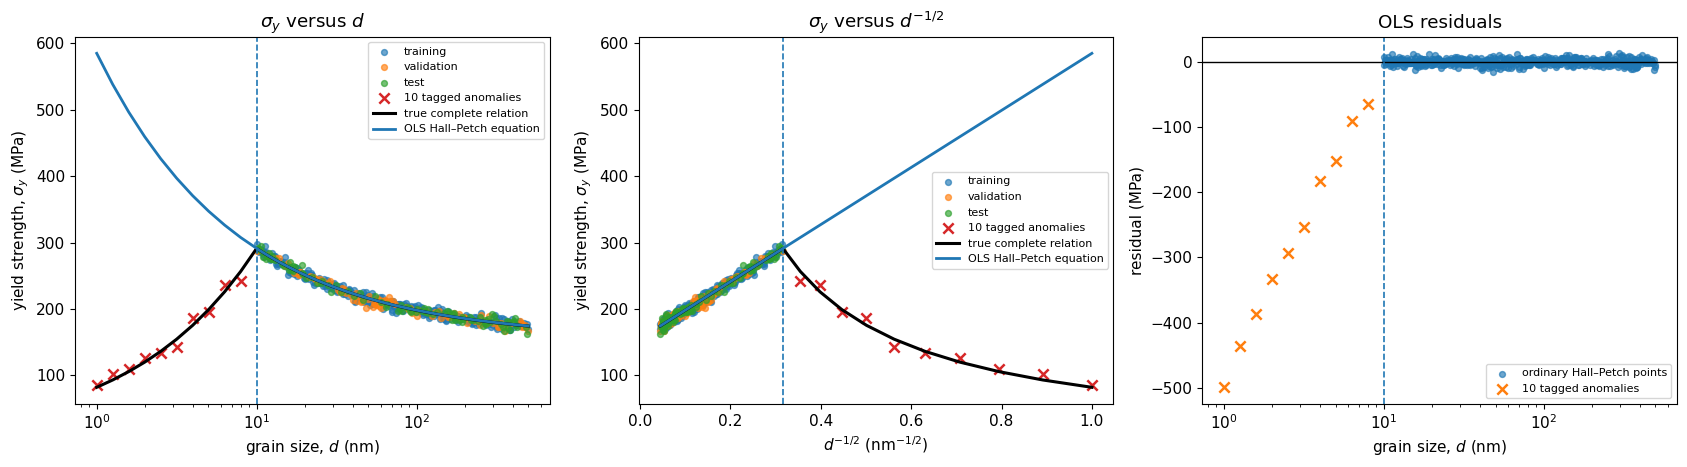

In [5]:
# Sort separately for d and d^(-1/2).
order_d = np.argsort(d_nm)
order_x = np.argsort(x_hp)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

# ------------------------------------------------------------
# 1. Yield strength versus grain size
# ------------------------------------------------------------
axes[0].scatter(
    d_nm[train_idx],
    sigma_measured[train_idx],
    s=18,
    alpha=0.65,
    label="training"
)
axes[0].scatter(
    d_nm[val_idx],
    sigma_measured[val_idx],
    s=18,
    alpha=0.65,
    label="validation"
)
axes[0].scatter(
    d_nm[test_idx],
    sigma_measured[test_idx],
    s=18,
    alpha=0.65,
    label="test"
)
axes[0].scatter(
    d_nm[inverse_idx],
    sigma_measured[inverse_idx],
    marker="x",
    s=55,
    linewidths=1.8,
    label="10 tagged anomalies"
)
axes[0].plot(
    d_nm[order_d],
    sigma_true[order_d],
    color="black",
    linewidth=2.2,
    label="true complete relation"
)
axes[0].plot(
    d_nm[order_d],
    sigma_pred_ols[order_d],
    linewidth=2.0,
    label="OLS Hall–Petch equation"
)
axes[0].axvline(
    d_transition,
    linestyle="--",
    linewidth=1.2
)
axes[0].set_xscale("log")
axes[0].set_xlabel(r"grain size, $d$ (nm)")
axes[0].set_ylabel(r"yield strength, $\sigma_y$ (MPa)")
axes[0].set_title(r"$\sigma_y$ versus $d$")
axes[0].legend(fontsize=8)

# ------------------------------------------------------------
# 2. Conventional Hall–Petch coordinate
# ------------------------------------------------------------
axes[1].scatter(
    x_hp[train_idx],
    sigma_measured[train_idx],
    s=18,
    alpha=0.65,
    label="training"
)
axes[1].scatter(
    x_hp[val_idx],
    sigma_measured[val_idx],
    s=18,
    alpha=0.65,
    label="validation"
)
axes[1].scatter(
    x_hp[test_idx],
    sigma_measured[test_idx],
    s=18,
    alpha=0.65,
    label="test"
)
axes[1].scatter(
    x_hp[inverse_idx],
    sigma_measured[inverse_idx],
    marker="x",
    s=55,
    linewidths=1.8,
    label="10 tagged anomalies"
)
axes[1].plot(
    x_hp[order_x],
    sigma_true[order_x],
    color="black",
    linewidth=2.2,
    label="true complete relation"
)
axes[1].plot(
    x_hp[order_x],
    sigma_pred_ols[order_x],
    linewidth=2.0,
    label="OLS Hall–Petch equation"
)
axes[1].axvline(
    d_transition**(-0.5),
    linestyle="--",
    linewidth=1.2
)
axes[1].set_xlabel(r"$d^{-1/2}$ (nm$^{-1/2}$)")
axes[1].set_ylabel(r"yield strength, $\sigma_y$ (MPa)")
axes[1].set_title(r"$\sigma_y$ versus $d^{-1/2}$")
axes[1].legend(fontsize=8)

# ------------------------------------------------------------
# 3. Residuals versus grain size
# ------------------------------------------------------------
axes[2].axhline(
    0.0,
    color="black",
    linewidth=1
)
axes[2].scatter(
    d_nm[hp_idx],
    residuals_ols[hp_idx],
    s=18,
    alpha=0.65,
    label="ordinary Hall–Petch points"
)
axes[2].scatter(
    d_nm[inverse_idx],
    residuals_ols[inverse_idx],
    marker="x",
    s=55,
    linewidths=1.8,
    label="10 tagged anomalies"
)
axes[2].axvline(
    d_transition,
    linestyle="--",
    linewidth=1.2
)
axes[2].set_xscale("log")
axes[2].set_xlabel(r"grain size, $d$ (nm)")
axes[2].set_ylabel("residual (MPa)")
axes[2].set_title("OLS residuals")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


## A Good Fit Is Not Necessarily the Complete Physics

Suppose the analyst decides that the ten observations below $10$ nm are merely
experimental scatter or anomalous measurements and removes them from the
analysis.

Only the dominant ordinary Hall–Petch regime is then retained:

$$
d\geq d_{\mathrm{transition}}=10\ \mathrm{nm}.
$$

In the conventional Hall–Petch coordinate, this corresponds to

$$
d^{-1/2}\leq d_{\mathrm{transition}}^{-1/2}.
$$

The remaining 500 observations follow

$$
\sigma_y=\sigma_0+k d^{-1/2}
$$

very closely. The OLS fit therefore appears highly successful.

However, this result does not establish that the Hall–Petch equation describes
the complete grain-size dependence. It establishes only that the equation
describes the subset of data retained by the analyst.

The ten neglected observations are not random in this synthetic example. They
form a systematic inverse Hall–Petch branch. Removing them improves the apparent
fit while simultaneously removing the evidence for a change in deformation
mechanism.

This illustrates an important distinction:

> **Curve fitting identifies the best parameters within the supplied model and
> selected dataset. It does not, by itself, establish the underlying physics.**

A high $R^2$, a low RMSE, or visually random residuals can support a model only
over the domain that was actually examined. Physical interpretation also
requires inspecting excluded observations, the range of validity, residual
structure, and possible changes in mechanism.

The dominant 500-point population should scatter randomly around the OLS equation and around zero in the residual plot.

The ten excluded points should form a small but systematic group. Calling them “anomalies” is an initial data-analysis label, not a final physical conclusion. Their coherent trend suggests that they are not merely random measurement errors and motivates a more flexible model.


Number of retained observations = 500
Number of neglected observations = 10
RMSE over retained regime = 4.79 MPa
R² over retained regime   = 0.97914


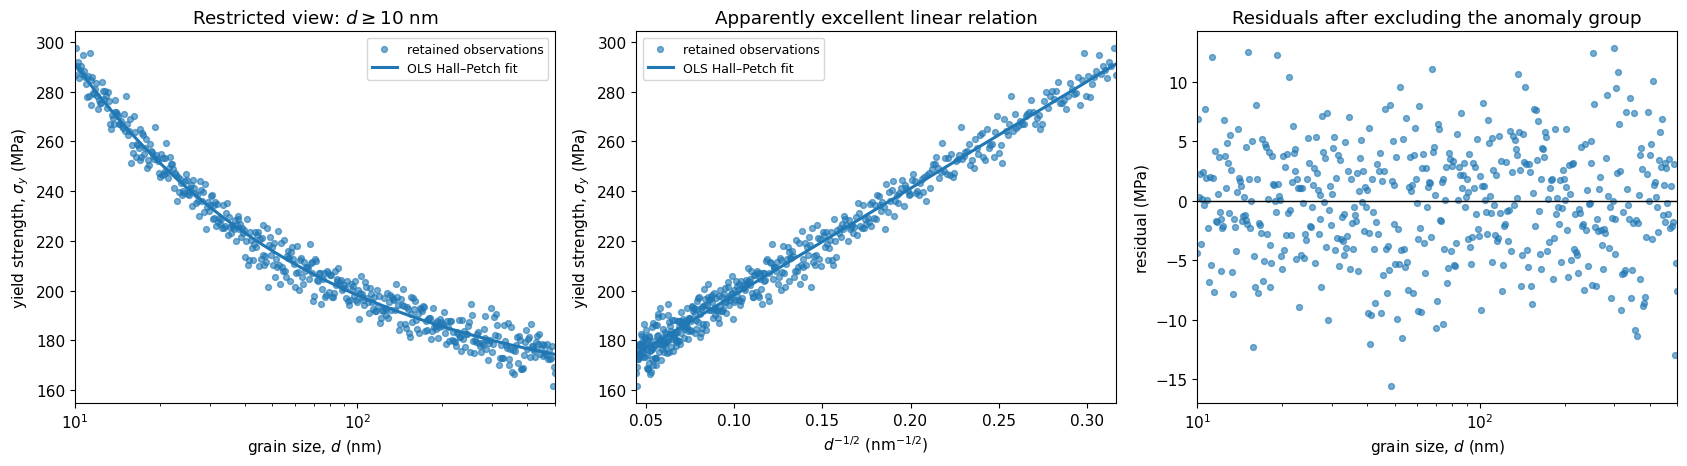

In [6]:
# ------------------------------------------------------------
# Deliberately incomplete analysis:
# retain only the ordinary Hall–Petch regime
# ------------------------------------------------------------

# Keep only observations at or above the transition grain size.
retained_mask = d_nm >= d_transition
retained_idx = np.flatnonzero(retained_mask)

# In the Hall–Petch coordinate, this is equivalent to retaining
# x = d^(-1/2) values at or below the transition coordinate.
x_transition = d_transition**(-0.5)

# Sort the retained observations for smooth plotting.
order_retained_d = retained_idx[
    np.argsort(d_nm[retained_idx])
]

order_retained_x = retained_idx[
    np.argsort(x_hp[retained_idx])
]

# Calculate ordinary-regime goodness-of-fit measures.
retained_residuals = (
    sigma_measured[retained_idx]
    - sigma_pred_ols[retained_idx]
)

retained_rmse = rmse(
    sigma_measured[retained_idx],
    sigma_pred_ols[retained_idx]
)

ss_res = np.sum(
    retained_residuals**2
)

ss_tot = np.sum(
    (
        sigma_measured[retained_idx]
        - np.mean(sigma_measured[retained_idx])
    )**2
)

retained_r2 = 1.0 - ss_res / ss_tot

print(
    f"Number of retained observations = "
    f"{len(retained_idx)}"
)

print(
    f"Number of neglected observations = "
    f"{len(inverse_idx)}"
)

print(
    f"RMSE over retained regime = "
    f"{retained_rmse:.2f} MPa"
)

print(
    f"R² over retained regime   = "
    f"{retained_r2:.5f}"
)

# ------------------------------------------------------------
# Plot only the retained regime
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 4.8)
)

# 1. Strength versus grain size:
# the inverse Hall–Petch points are not shown.
axes[0].scatter(
    d_nm[retained_idx],
    sigma_measured[retained_idx],
    s=18,
    alpha=0.60,
    label="retained observations"
)

axes[0].plot(
    d_nm[order_retained_d],
    sigma_pred_ols[order_retained_d],
    linewidth=2.2,
    label="OLS Hall–Petch fit"
)

axes[0].set_xscale("log")

axes[0].set_xlim(
    d_transition,
    d_nm.max()
)

axes[0].set_xlabel(
    r"grain size, $d$ (nm)"
)

axes[0].set_ylabel(
    r"yield strength, $\sigma_y$ (MPa)"
)

axes[0].set_title(
    r"Restricted view: $d\geq10$ nm"
)

axes[0].legend(
    fontsize=9
)

# 2. Conventional Hall–Petch plot:
# only x <= x_transition is displayed.
axes[1].scatter(
    x_hp[retained_idx],
    sigma_measured[retained_idx],
    s=18,
    alpha=0.60,
    label="retained observations"
)

axes[1].plot(
    x_hp[order_retained_x],
    sigma_pred_ols[order_retained_x],
    linewidth=2.2,
    label="OLS Hall–Petch fit"
)

axes[1].set_xlim(
    x_hp[retained_idx].min(),
    x_transition
)

axes[1].set_xlabel(
    r"$d^{-1/2}$ (nm$^{-1/2}$)"
)

axes[1].set_ylabel(
    r"yield strength, $\sigma_y$ (MPa)"
)

axes[1].set_title(
    r"Apparently excellent linear relation"
)

axes[1].legend(
    fontsize=9
)

# 3. Residuals for the retained regime only.
axes[2].axhline(
    0.0,
    color="black",
    linewidth=1
)

axes[2].scatter(
    d_nm[retained_idx],
    retained_residuals,
    s=18,
    alpha=0.60
)

axes[2].set_xscale("log")

axes[2].set_xlim(
    d_transition,
    d_nm.max()
)

axes[2].set_xlabel(
    r"grain size, $d$ (nm)"
)

axes[2].set_ylabel(
    "residual (MPa)"
)

axes[2].set_title(
    "Residuals after excluding the anomaly group"
)

plt.tight_layout()
plt.show()

## Recover the Same Hall–Petch Parameters by Gradient-Based Fitting

The same ordinary Hall–Petch training subset is fitted with a gradient-based optimizer:

$$
\widehat{\sigma}_y=\sigma_0+k d^{-1/2}.
$$

Only $\sigma_0$ and $k$ are trainable. The ten anomaly points remain excluded from this two-parameter fit, exactly as in the OLS calculation.


The gradient-trained values should agree closely with OLS. The difference is the optimization algorithm, not the represented equation. To recover a named constitutive form, that form must be imposed or identified using a separate symbolic/model-selection procedure.

In [7]:
import torch
import torch.nn as nn

# Use GPU when available; otherwise use CPU.
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Floating-point precision used throughout this cell.
DTYPE = torch.float32


def to_tensor(array):
    """Convert a NumPy array to a PyTorch tensor on DEVICE."""
    return torch.as_tensor(
        array,
        dtype=DTYPE,
        device=DEVICE
    )


# Define the supplied Hall–Petch equation as a PyTorch model.
class GradientHallPetch(nn.Module):
    def __init__(self):
        super().__init__()

        # Initialize the two trainable physical parameters.
        self.sigma0 = nn.Parameter(
            torch.tensor(
                100.0,
                dtype=DTYPE,
                device=DEVICE
            )
        )

        self.k = nn.Parameter(
            torch.tensor(
                300.0,
                dtype=DTYPE,
                device=DEVICE
            )
        )

    def forward(self, d):
        return self.sigma0 + self.k * d.pow(-0.5)


# Use exactly the same ordinary Hall–Petch training subset as OLS.
d_train_tensor = to_tensor(
    d_nm[train_idx, None]
)

sigma_train_tensor = to_tensor(
    sigma_measured[train_idx, None]
)

# Create the model.
gradient_hp_model = GradientHallPetch()

# Define the optimizer.
optimizer_hp = torch.optim.Adam(
    gradient_hp_model.parameters(),
    lr=2.0e-2
)

# Train the two Hall–Petch parameters.
for epoch in range(6000):
    optimizer_hp.zero_grad()

    prediction = gradient_hp_model(
        d_train_tensor
    )

    loss = torch.mean(
        (prediction - sigma_train_tensor)**2
    )

    loss.backward()
    optimizer_hp.step()

# Extract the fitted parameters.
sigma0_gradient = (
    gradient_hp_model.sigma0
    .detach()
    .cpu()
    .item()
)

k_gradient = (
    gradient_hp_model.k
    .detach()
    .cpu()
    .item()
)

print(
    f"Gradient-fit sigma0 = "
    f"{sigma0_gradient:.2f} MPa"
)

print(
    f"Gradient-fit k      = "
    f"{k_gradient:.2f} MPa nm^(1/2)"
)

print()

print(
    f"OLS sigma0          = "
    f"{sigma0_ols:.2f} MPa"
)

print(
    f"OLS k               = "
    f"{k_ols:.2f} MPa nm^(1/2)"
)

Gradient-fit sigma0 = 163.44 MPa
Gradient-fit k      = 370.30 MPa nm^(1/2)

OLS sigma0          = 155.20 MPa
OLS k               = 429.57 MPa nm^(1/2)


# Part II — Neural networks as flexible functions

## One neuron and one forward calculation

A **weight** multiplies an input, a **bias** is added, and an **activation function** applies a fixed nonlinear transformation. For one input $x$,

$$
z=wx+b,\qquad h=\tanh(z).
$$

The next cell calculates every number explicitly. No learning occurs during a forward calculation.

In [8]:
# Work through one neuron by hand before training a network.
x_demo = 0.8
w_demo = 1.7
b_demo = -0.2
z_demo = w_demo*x_demo + b_demo
h_demo = np.tanh(z_demo)

print("input x              =", x_demo)
print("weight times input   =", w_demo*x_demo)
print("add bias: z          =", z_demo)
print("apply tanh: output h =", h_demo)

input x              = 0.8
weight times input   = 1.36
add bias: z          = 1.1600000000000001
apply tanh: output h = 0.8210398813328772


Training is a separate process that changes the weight and bias. A forward calculation only evaluates the current function.

## Use the Same Dataset for Nonlinear Neural-Network Fitting

No second grain-size dataset is generated.

The neural network uses the same 510 observations:

- the same 500 ordinary Hall–Petch observations;
- the same 10 tagged anomaly observations.

The ordinary 500-point population retains the train–validation–test split defined earlier. Because the anomaly group contains only ten points, those ten observations are added to the neural-network training subset rather than being subdivided into statistically meaningless validation and test groups.

Thus:

- validation and test metrics measure generalization in the dominant ordinary Hall–Petch regime;
- the full-data plot shows whether the flexible model also captures the small anomalous branch.


In [9]:
# Reuse the same common dataset.
d_nn = d_nm
strength_obs = sigma_measured
strength_true = sigma_true

# Keep the ordinary Hall–Petch validation and test subsets unchanged.
# Add all ten anomaly points to the neural-network training subset.
nn_train = np.concatenate([
    train_idx,
    inverse_idx
])
nn_val = val_idx
nn_test = test_idx

# Use log10(d) as the neural-network input because d spans
# nearly three orders of magnitude from 1 to 500 nm.
logd = np.log10(d_nn)

# Compute scaling constants from the neural-network training subset only.
x_mean = logd[nn_train].mean()
x_std = logd[nn_train].std()

y_mean = strength_obs[nn_train].mean()
y_std = strength_obs[nn_train].std()

x_scaled = (logd - x_mean) / x_std
y_scaled = (strength_obs - y_mean) / y_std

print(
    "Neural-network training/validation/test sizes:",
    len(nn_train),
    len(nn_val),
    len(nn_test)
)
print(
    "The neural-network training subset contains all 10 anomaly points."
)


Neural-network training/validation/test sizes: 310 100 100
The neural-network training subset contains all 10 anomaly points.


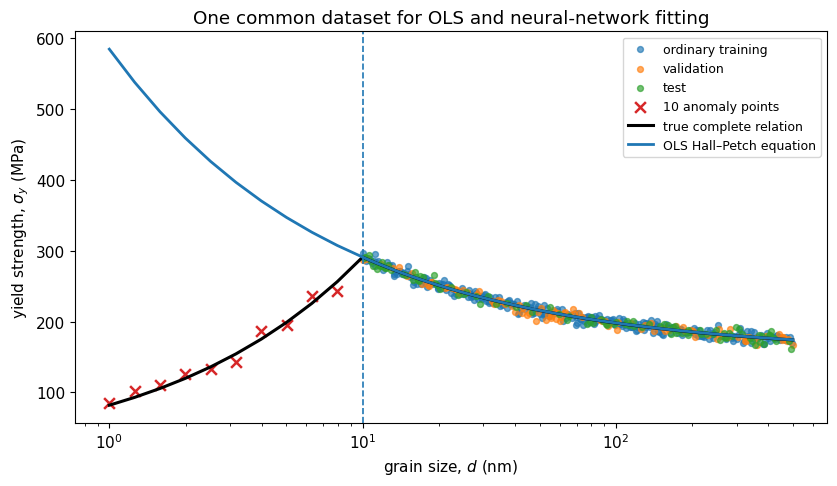

In [10]:
# Plot the shared dataset before neural-network training.
order_d = np.argsort(d_nn)

plt.figure(figsize=(8.5, 5.0))

plt.scatter(
    d_nn[train_idx],
    strength_obs[train_idx],
    s=18,
    alpha=0.65,
    label="ordinary training"
)
plt.scatter(
    d_nn[nn_val],
    strength_obs[nn_val],
    s=18,
    alpha=0.65,
    label="validation"
)
plt.scatter(
    d_nn[nn_test],
    strength_obs[nn_test],
    s=18,
    alpha=0.65,
    label="test"
)
plt.scatter(
    d_nn[inverse_idx],
    strength_obs[inverse_idx],
    marker="x",
    s=60,
    linewidths=1.8,
    label="10 anomaly points"
)
plt.plot(
    d_nn[order_d],
    strength_true[order_d],
    color="black",
    linewidth=2.2,
    label="true complete relation"
)
plt.plot(
    d_nn[order_d],
    sigma_pred_ols[order_d],
    linewidth=2.0,
    label="OLS Hall–Petch equation"
)

plt.axvline(
    d_transition,
    linestyle="--",
    linewidth=1.2
)
plt.xscale("log")
plt.xlabel(r"grain size, $d$ (nm)")
plt.ylabel(r"yield strength, $\sigma_y$ (MPa)")
plt.title("One common dataset for OLS and neural-network fitting")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


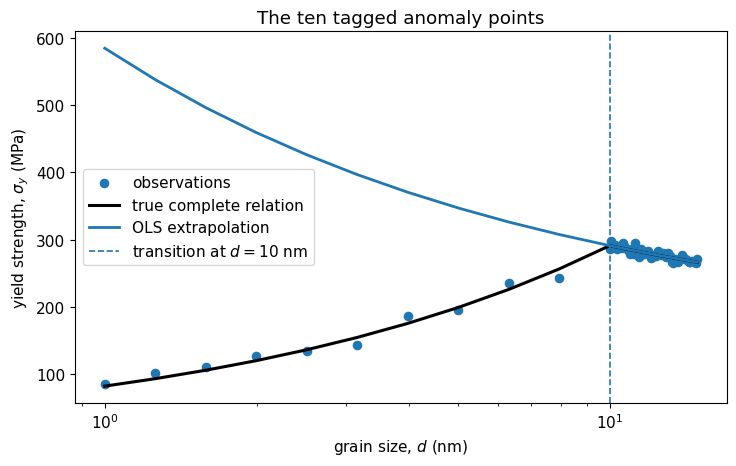

In [11]:
# Enlarge the 1-15 nm region containing the branch transition.
small_region = d_nn <= 15.0
small_order = np.argsort(d_nn[small_region])

plt.figure(figsize=(7.5, 4.8))

plt.scatter(
    d_nn[small_region],
    strength_obs[small_region],
    s=35,
    label="observations"
)
plt.plot(
    d_nn[small_region][small_order],
    strength_true[small_region][small_order],
    color="black",
    linewidth=2.2,
    label="true complete relation"
)
plt.plot(
    d_nn[small_region][small_order],
    sigma_pred_ols[small_region][small_order],
    linewidth=2.0,
    label="OLS extrapolation"
)
plt.axvline(
    d_transition,
    linestyle="--",
    linewidth=1.2,
    label=r"transition at $d=10$ nm"
)

plt.xscale("log")
plt.xlabel(r"grain size, $d$ (nm)")
plt.ylabel(r"yield strength, $\sigma_y$ (MPa)")
plt.title("The ten tagged anomaly points")
plt.legend()
plt.tight_layout()
plt.show()


The neural network is not given a separate anomaly equation. It sees the same measured observations.

The imbalance is severe: 500 ordinary Hall–Petch points versus only 10 inverse Hall–Petch points. This is intentional. It illustrates why a small systematic physical regime can be overlooked when the dominant population controls the analysis.


## Define a small multilayer perceptron and a training procedure

A multilayer perceptron (MLP) composes linear transformations and activation functions. The training function below records training and validation losses, supports early stopping, and can restore the parameter values with the lowest validation loss.

In [12]:
# Define a small fully connected neural network.
class MLP(nn.Module):

    def __init__(self, widths, activation=nn.Tanh):
        super().__init__()

        # Start with one input feature: scaled log10(grain size).
        input_size = 1

        # Store the layers in a Python list before combining them.
        layers = []

        # Add the hidden layers.
        for width in widths:
            layers.append(nn.Linear(input_size, width))
            layers.append(activation())

            # The output size of this layer becomes the input size
            # of the next layer.
            input_size = width

        # Add the final output layer.
        # The network predicts one value: scaled yield strength.
        layers.append(nn.Linear(input_size, 1))

        # Combine all layers into one sequential model.
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # Pass the input through the complete network.
        return self.net(x)


# Train a neural network using training and validation data.
def fit_supervised(
    model,
    x_train,
    y_train,
    x_val,
    y_val,
    epochs=1500,
    learning_rate=1e-3,
    patience=150,
    restore_best=True
):
    # Move the model to the selected device.
    # This may be the CPU, GPU, or Apple MPS device.
    model = model.to(device)

    # Adam adjusts the network weights during training.
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    # Store the training and validation losses after each epoch.
    history = {
        "train": [],
        "val": []
    }

    # Keep track of the best validation result.
    best_val_loss = np.inf
    best_state = None
    best_epoch = None

    # Count how many consecutive epochs show no validation improvement.
    epochs_without_improvement = 0

    for epoch in range(epochs):

        # -------------------------
        # Training step
        # -------------------------
        model.train()

        # Remove gradients left from the previous epoch.
        optimizer.zero_grad()

        # Predict the training values.
        y_train_pred = model(x_train)

        # Mean squared error between prediction and observation.
        train_loss = torch.mean(
            (y_train_pred - y_train) ** 2
        )

        # Calculate gradients of the loss.
        train_loss.backward()

        # Update the network weights.
        optimizer.step()

        # -------------------------
        # Validation step
        # -------------------------
        model.eval()

        # No gradients are needed during validation.
        with torch.no_grad():
            y_val_pred = model(x_val)

            val_loss = torch.mean(
                (y_val_pred - y_val) ** 2
            )

        # Convert the losses to ordinary Python numbers.
        train_loss_value = train_loss.item()
        val_loss_value = val_loss.item()

        # Save the loss history.
        history["train"].append(train_loss_value)
        history["val"].append(val_loss_value)

        # Check whether the validation loss has improved.
        if val_loss_value < best_val_loss:
            best_val_loss = val_loss_value
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        # Stop if the validation loss has not improved
        # for the specified number of epochs.
        if restore_best and epochs_without_improvement >= patience:
            break

    # Restore the weights from the epoch with the lowest validation loss.
    if restore_best and best_state is not None:
        model.load_state_dict(best_state)

    # Store useful information about the best model.
    best = {
        "val_loss": best_val_loss,
        "epoch": best_epoch,
        "state_dict": best_state
    }

    return model, history, best

The optimizer sees only training labels. Validation loss is calculated without a parameter update. Early stopping chooses an epoch using validation data; it must not use the test set.

## Train an underfitting, balanced and overfitting model

The models use the same training observations but different capacities and stopping rules:

- the underfitting model is only a straight line;
- the balanced model is a modest two-layer network selected by validation loss;
- the overfitting model is much larger and is allowed to continue fitting the small noisy training set.

In [13]:
# Convert the training inputs and outputs to PyTorch tensors.
# [:, None] changes each one-dimensional array into a column vector.
x_train_tensor = to_tensor(x_scaled[nn_train, None])
y_train_tensor = to_tensor(y_scaled[nn_train, None])

# Convert the validation inputs and outputs to PyTorch tensors.
x_val_tensor = to_tensor(x_scaled[nn_val, None])
y_val_tensor = to_tensor(y_scaled[nn_val, None])



# Model 1: too simple


# Reset the random seed so that weight initialization is reproducible.
torch.manual_seed(SEED)

# MLP([]) has no hidden layer.
# It is only a linear relation between the input and output.
# It cannot reproduce the curved strength–grain-size relation.
under_model, under_history, under_best = fit_supervised(
    model=MLP([]),
    x_train=x_train_tensor,
    y_train=y_train_tensor,
    x_val=x_val_tensor,
    y_val=y_val_tensor,
    epochs=900,
    learning_rate=3e-3,
    patience=150,
    restore_best=True
)


# ------------------------------------------------------------
# Model 2: suitable capacity
# ------------------------------------------------------------

# Reset the seed so that comparisons between models are reproducible.
torch.manual_seed(SEED)

# This network has two hidden layers with 64 neurons in each layer.
# It has enough flexibility to learn the two branches without being excessive.
right_model, right_history, right_best = fit_supervised(
    model=MLP([64, 64]),
    x_train=x_train_tensor,
    y_train=y_train_tensor,
    x_val=x_val_tensor,
    y_val=y_val_tensor,
    epochs=2200,
    learning_rate=2e-3,
    patience=220,
    restore_best=True
)


# ------------------------------------------------------------
# Model 3: unnecessarily large
# ------------------------------------------------------------

# Reset the seed again for reproducibility.
torch.manual_seed(SEED)

# This network has three hidden layers with 128 neurons in each layer.
# It has far more parameters than needed for this small dataset.
#
# restore_best=False means that the final model is retained,
# even if its validation loss became worse during later epochs.
# This is done deliberately to demonstrate overfitting.
over_model, over_history, over_best = fit_supervised(
    model=MLP(
        widths=[128, 128, 128],
        activation=nn.ReLU
    ),
    x_train=x_train_tensor,
    y_train=y_train_tensor,
    x_val=x_val_tensor,
    y_val=y_val_tensor,
    epochs=2600,
    learning_rate=2e-3,
    patience=2600,
    restore_best=False
)


# Report the epoch at which each model had its lowest validation loss.
# Epoch numbering starts from zero in Python, so add 1 for display.
print(
    "Balanced model selected epoch:",
    right_best["epoch"] + 1
)

print(
    "Large model lowest validation-loss epoch:",
    over_best["epoch"] + 1
)

print(
    "The final large-model epoch was retained deliberately "
    "to show overfitting."
)


Balanced model selected epoch: 731
Large model lowest validation-loss epoch: 81
The final large-model epoch was retained deliberately to show overfitting.


The large model is intentionally not restored to its best validation epoch. That is a teaching choice made to expose what can happen when training continues after validation performance stops improving.

##  Compare OLS and Neural-Network Fits on the Same Dataset

The comparison uses the same 510 measured observations.

OLS is evaluated as the ordinary Hall–Petch model fitted to the dominant 500-point regime. The neural network is trained on the ordinary training subset plus all ten tagged anomaly points.

The comparison therefore asks two separate questions:

- Does the model generalize to held-out ordinary Hall–Petch observations?
- Can it also represent the small systematic branch that was initially labeled anomalous scatter?


underfit  ordinary train/validation/test RMSE =  15.45 /  13.98 /  18.77 MPa; anomaly RMSE = 127.51 MPa
balanced  ordinary train/validation/test RMSE =   4.81 /   4.76 /   5.09 MPa; anomaly RMSE =   8.57 MPa
overfit   ordinary train/validation/test RMSE =   4.41 /   5.22 /   5.18 MPa; anomaly RMSE =   2.76 MPa
OLS       ordinary train/validation/test RMSE =   4.75 /   4.87 /   4.80 MPa; anomaly RMSE = 303.01 MPa


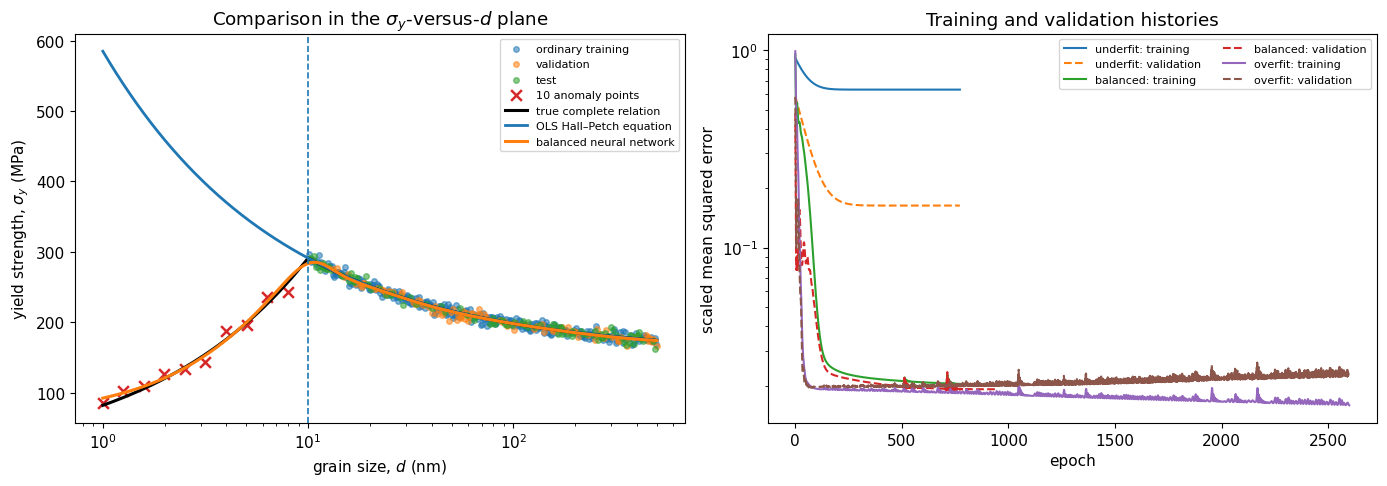

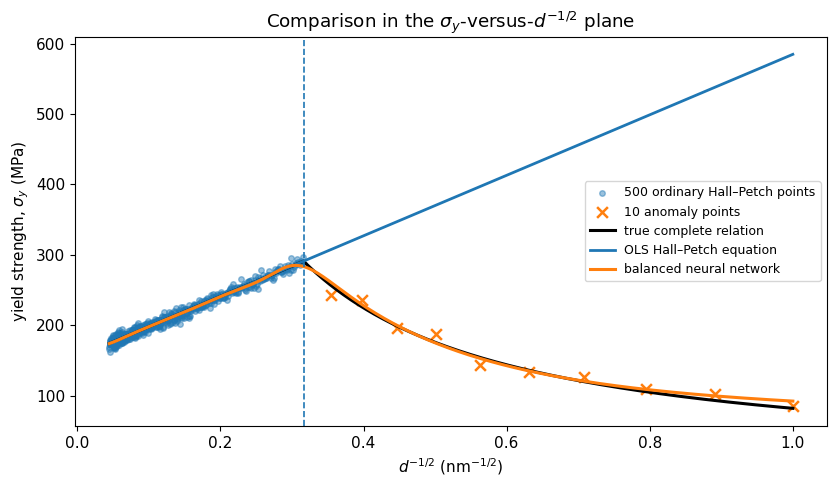

In [14]:
# Convert a neural-network output back to physical strength units.
def predict_strength(model, d_values):
    z = (
        np.log10(d_values)
        - x_mean
    ) / x_std

    model.eval()

    with torch.no_grad():
        prediction_scaled = (
            model(to_tensor(z[:, None]))
            .cpu()
            .numpy()
            .ravel()
        )

    return prediction_scaled * y_std + y_mean


models = {
    "underfit": under_model,
    "balanced": right_model,
    "overfit": over_model
}

# Evaluate ordinary validation and test performance.
for name, model in models.items():
    prediction_all = predict_strength(
        model,
        d_nn
    )

    ordinary_errors = [
        rmse(
            strength_obs[idx],
            prediction_all[idx]
        )
        for idx in (
            train_idx,
            nn_val,
            nn_test
        )
    ]

    anomaly_error = rmse(
        strength_obs[inverse_idx],
        prediction_all[inverse_idx]
    )

    print(
        f"{name:9s} ordinary train/validation/test RMSE = "
        f"{ordinary_errors[0]:6.2f} / "
        f"{ordinary_errors[1]:6.2f} / "
        f"{ordinary_errors[2]:6.2f} MPa; "
        f"anomaly RMSE = {anomaly_error:6.2f} MPa"
    )

ols_errors = [
    rmse(
        strength_obs[idx],
        sigma_pred_ols[idx]
    )
    for idx in (
        train_idx,
        nn_val,
        nn_test
    )
]

ols_anomaly_error = rmse(
    strength_obs[inverse_idx],
    sigma_pred_ols[inverse_idx]
)

print(
    f"{'OLS':9s} ordinary train/validation/test RMSE = "
    f"{ols_errors[0]:6.2f} / "
    f"{ols_errors[1]:6.2f} / "
    f"{ols_errors[2]:6.2f} MPa; "
    f"anomaly RMSE = {ols_anomaly_error:6.2f} MPa"
)

# Dense coordinates for smooth fitted curves.
d_dense = np.geomspace(
    d_nn.min(),
    d_nn.max(),
    800
)

x_dense = d_dense**(-0.5)

X_dense = np.column_stack([
    np.ones_like(x_dense),
    x_dense
])

ols_dense = X_dense @ beta_ols

sigma_hp_dense = (
    sigma0_true
    + k_true / np.sqrt(d_dense)
)

sigma_inverse_dense = sigma_transition * (
    d_dense / d_transition
)**inverse_exponent

truth_dense = np.where(
    d_dense < d_transition,
    sigma_inverse_dense,
    sigma_hp_dense
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5.0)
)

# ------------------------------------------------------------
# Complete physical plot against d
# ------------------------------------------------------------
axes[0].scatter(
    d_nn[train_idx],
    strength_obs[train_idx],
    s=16,
    alpha=0.55,
    label="ordinary training"
)
axes[0].scatter(
    d_nn[nn_val],
    strength_obs[nn_val],
    s=16,
    alpha=0.55,
    label="validation"
)
axes[0].scatter(
    d_nn[nn_test],
    strength_obs[nn_test],
    s=16,
    alpha=0.55,
    label="test"
)
axes[0].scatter(
    d_nn[inverse_idx],
    strength_obs[inverse_idx],
    marker="x",
    s=60,
    linewidths=1.8,
    label="10 anomaly points"
)
axes[0].plot(
    d_dense,
    truth_dense,
    color="black",
    linewidth=2.2,
    label="true complete relation"
)
axes[0].plot(
    d_dense,
    ols_dense,
    linewidth=2.0,
    label="OLS Hall–Petch equation"
)
axes[0].plot(
    d_dense,
    predict_strength(
        right_model,
        d_dense
    ),
    linewidth=2.2,
    label="balanced neural network"
)
axes[0].axvline(
    d_transition,
    linestyle="--",
    linewidth=1.2
)
axes[0].set_xscale("log")
axes[0].set_xlabel(r"grain size, $d$ (nm)")
axes[0].set_ylabel(r"yield strength, $\sigma_y$ (MPa)")
axes[0].set_title(r"Comparison in the $\sigma_y$-versus-$d$ plane")
axes[0].legend(fontsize=8)

# ------------------------------------------------------------
# Training histories
# ------------------------------------------------------------
for name, history in [
    ("underfit", under_history),
    ("balanced", right_history),
    ("overfit", over_history)
]:
    axes[1].plot(
        history["train"],
        label=f"{name}: training"
    )
    axes[1].plot(
        history["val"],
        "--",
        label=f"{name}: validation"
    )

axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("scaled mean squared error")
axes[1].set_title("Training and validation histories")
axes[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Separate Hall–Petch-coordinate comparison
# ------------------------------------------------------------
x_dense_order = np.argsort(x_dense)

plt.figure(figsize=(8.5, 5.0))

plt.scatter(
    x_hp[hp_idx],
    strength_obs[hp_idx],
    s=16,
    alpha=0.45,
    label="500 ordinary Hall–Petch points"
)
plt.scatter(
    x_hp[inverse_idx],
    strength_obs[inverse_idx],
    marker="x",
    s=60,
    linewidths=1.8,
    label="10 anomaly points"
)
plt.plot(
    x_dense[x_dense_order],
    truth_dense[x_dense_order],
    color="black",
    linewidth=2.2,
    label="true complete relation"
)
plt.plot(
    x_dense[x_dense_order],
    ols_dense[x_dense_order],
    linewidth=2.0,
    label="OLS Hall–Petch equation"
)
plt.plot(
    x_dense[x_dense_order],
    predict_strength(
        right_model,
        d_dense
    )[x_dense_order],
    linewidth=2.2,
    label="balanced neural network"
)

plt.axvline(
    d_transition**(-0.5),
    linestyle="--",
    linewidth=1.2
)
plt.xlabel(r"$d^{-1/2}$ (nm$^{-1/2}$)")
plt.ylabel(r"yield strength, $\sigma_y$ (MPa)")
plt.title(r"Comparison in the $\sigma_y$-versus-$d^{-1/2}$ plane")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


The ordinary Hall–Petch validation and test errors should remain small for both OLS and a suitably trained neural network.

The major difference appears in the ten-point anomaly group:

- the OLS equation extrapolates the ordinary Hall–Petch line and cannot turn downward;
- the balanced neural network can represent the complete nonmonotonic relation if the ten points are sufficiently weighted by their inclusion in training.

The lesson is not that OLS is inferior. OLS accurately estimates the parameters of the prescribed ordinary Hall–Petch model. The neural network answers a different question: whether one flexible function can describe both regimes in the same dataset.


##  Bias and Variance

Suppose the measured output at an input $x$ is

$$
y = f(x) + \epsilon,
$$

where

- $f(x)$ is the true relation between the input and output,
- $\epsilon$ is random measurement noise,
- $\mathbb{E}[\epsilon]=0$,
- $\operatorname{Var}(\epsilon)=\sigma_\epsilon^2$.

A model fitted to a training dataset gives the prediction

$$
\widehat{f}(x).
$$

The hat indicates that $\widehat{f}(x)$ is estimated from data. If we used a different training dataset, we would generally obtain a different fitted model and therefore a different value of $\widehat{f}(x)$.

We want to understand the expected squared prediction error at a fixed input $x$:

$$
\mathbb{E}
\left[
\left(
y-\widehat{f}(x)
\right)^2
\right].
$$

Substituting $y=f(x)+\epsilon$ gives

$$
\mathbb{E}
\left[
\left(
f(x)+\epsilon-\widehat{f}(x)
\right)^2
\right].
$$

Rearranging the terms,

$$
\mathbb{E}
\left[
\left(
f(x)-\widehat{f}(x)+\epsilon
\right)^2
\right].
$$

Expanding the square gives

$$
\mathbb{E}
\left[
\left(
f(x)-\widehat{f}(x)
\right)^2
\right]
+
2\mathbb{E}
\left[
\epsilon
\left(
f(x)-\widehat{f}(x)
\right)
\right]
+
\mathbb{E}[\epsilon^2].
$$

The noise is assumed to have zero mean and to be independent of the fitted model. Therefore, the middle term is zero:

$$
\mathbb{E}
\left[
\epsilon
\left(
f(x)-\widehat{f}(x)
\right)
\right]
=0.
$$

Also,

$$
\mathbb{E}[\epsilon^2]
=
\sigma_\epsilon^2.
$$

Hence,

$$
\mathbb{E}
\left[
\left(
y-\widehat{f}(x)
\right)^2
\right]
=
\mathbb{E}
\left[
\left(
f(x)-\widehat{f}(x)
\right)^2
\right]
+
\sigma_\epsilon^2.
$$

We now separate the model error into bias and variance.

Let the average prediction over many possible training datasets be

$$
\mathbb{E}\left[\widehat{f}(x)\right].
$$

Add and subtract this average prediction:

$$
f(x)-\widehat{f}(x)
=
f(x)
-
\mathbb{E}\left[\widehat{f}(x)\right]
+
\mathbb{E}\left[\widehat{f}(x)\right]
-
\widehat{f}(x).
$$

Therefore,

$$
\mathbb{E}
\left[
\left(
f(x)-\widehat{f}(x)
\right)^2
\right]
=
\mathbb{E}
\left[
\left(
f(x)
-
\mathbb{E}\left[\widehat{f}(x)\right]
+
\mathbb{E}\left[\widehat{f}(x)\right]
-
\widehat{f}(x)
\right)^2
\right].
$$

After expanding, the cross term is zero because

$$
\mathbb{E}
\left[
\widehat{f}(x)
-
\mathbb{E}\left[\widehat{f}(x)\right]
\right]
=0.
$$

We obtain

$$
\mathbb{E}
\left[
\left(
f(x)-\widehat{f}(x)
\right)^2
\right]
=
\left(
f(x)
-
\mathbb{E}\left[\widehat{f}(x)\right]
\right)^2
+
\mathbb{E}
\left[
\left(
\widehat{f}(x)
-
\mathbb{E}\left[\widehat{f}(x)\right]
\right)^2
\right].
$$

The first term is the squared bias:

$$
\operatorname{Bias}\left[\widehat{f}(x)\right]^2
=
\left(
\mathbb{E}\left[\widehat{f}(x)\right]
-
f(x)
\right)^2.
$$

The second term is the variance:

$$
\operatorname{Variance}\left[\widehat{f}(x)\right]
=
\mathbb{E}
\left[
\left(
\widehat{f}(x)
-
\mathbb{E}\left[\widehat{f}(x)\right]
\right)^2
\right].
$$

Combining the results gives the bias–variance decomposition:

$$
\boxed{
\mathbb{E}
\left[
\left(
y-\widehat{f}(x)
\right)^2
\right]
=
\operatorname{Bias}\left[\widehat{f}(x)\right]^2
+
\operatorname{Variance}\left[\widehat{f}(x)\right]
+
\sigma_\epsilon^2
}
$$

### Meaning of the three terms

**Bias** measures how far the average prediction is from the true value $f(x)$.

A model with high bias is systematically wrong. This usually happens when the model is too simple to represent the true relation.

**Variance** measures how much the prediction changes when a different training dataset is used.

A model with high variance is very sensitive to the particular observations used for training. This usually happens when the model is too flexible for the available amount of data.

The term $\sigma_\epsilon^2$ is the noise variance. It represents random variation in the measurements and cannot be removed by improving the model.

Thus, the expected prediction error contains three contributions:

$$
\text{prediction error}
=
\text{squared bias}
+
\text{variance}
+
\text{irreducible noise}.
$$

A very simple model usually has high bias and low variance. A very flexible model usually has low training error but may have high variance. The aim is to find a model that gives a reasonable balance between the two.

Bias and variance describe behavior across many possible training datasets. They cannot be determined completely from one fitted model. In the next experiment, we generate many noisy datasets and fit polynomial models of different degrees to make these effects visible.



## Bias and Variance Using the Same Grain-Size Dataset

The physical dataset is not changed in this section.

We continue to use the same:

- 10 inverse Hall–Petch points between 1 and 10 nm;
- 500 ordinary Hall–Petch points between 10 and 500 nm;
- transition at 10 nm;
- training, validation, and test indices.

To estimate bias and variance, we imagine repeating the same experiment many
times at exactly the same 510 grain sizes. The underlying noise-free relation
remains unchanged. Only the random measurement noise differs between repeated
experiments.

This is essential: bias and variance are properties of a fitting procedure
under repeated sampling. They should not be demonstrated by silently changing
the physical relation or the grain-size domain.

Degree 1
  ordinary Hall–Petch bias² = 232.478
  inverse branch bias²       = 16833.247
  ordinary Hall–Petch variance = 0.155
  inverse branch variance      = 0.831

Degree 5
  ordinary Hall–Petch bias² = 43.597
  inverse branch bias²       = 297.598
  ordinary Hall–Petch variance = 0.375
  inverse branch variance      = 12.777

Degree 15
  ordinary Hall–Petch bias² = 2.413
  inverse branch bias²       = 20.454
  ordinary Hall–Petch variance = 0.951
  inverse branch variance      = 37.598



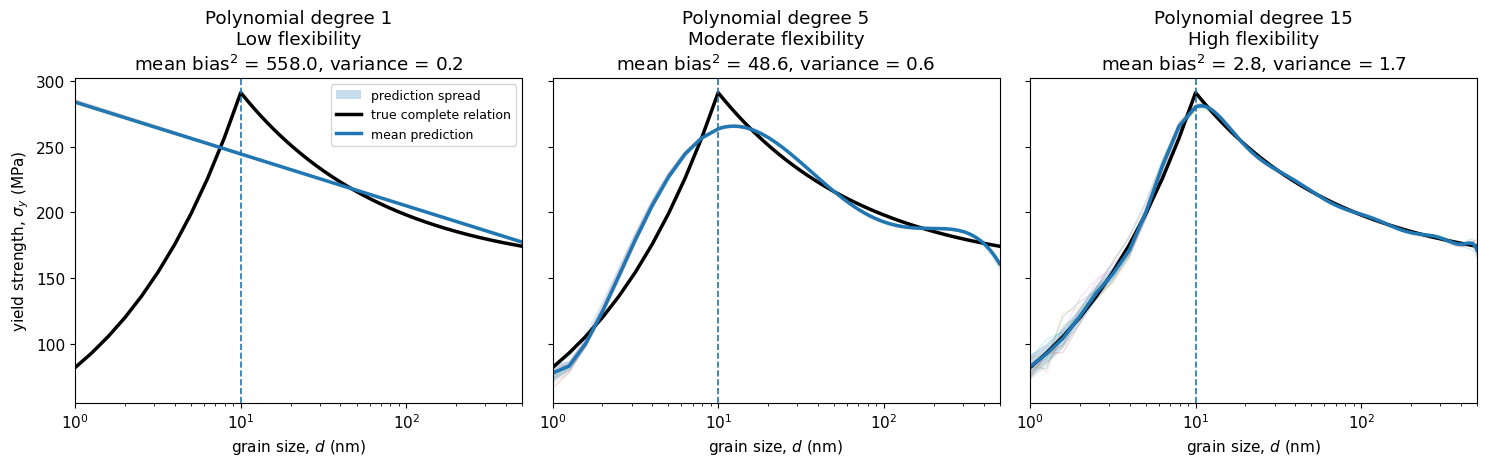

In [15]:
# Import the numerically stable polynomial fitting class.
from numpy.polynomial import Polynomial


# ------------------------------------------------------------
# Use the existing common dataset
# ------------------------------------------------------------

# The physical grain sizes are unchanged:
# 10 inverse Hall–Petch points from 1 to 10 nm and
# 500 ordinary Hall–Petch points from 10 to 500 nm.
z_all = np.log10(d_nm)

# Sort only for smooth plotting.
order_d = np.argsort(d_nm)

d_plot = d_nm[order_d]
z_plot = z_all[order_d]

# The true relation is the same one used throughout the notebook.
strength_true_plot = sigma_true[order_d]


# ------------------------------------------------------------
# Polynomial model capacities
# ------------------------------------------------------------

degrees = [1, 5, 15]

titles = [
    "Low flexibility",
    "Moderate flexibility",
    "High flexibility"
]


# ------------------------------------------------------------
# Repeated versions of the same experiment
# ------------------------------------------------------------

# Each repetition uses exactly the same 510 grain sizes
# and exactly the same underlying physical relation.
#
# Only the random measurement noise changes.
n_repeats = 100


fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4.8),
    sharex=True,
    sharey=True
)


for ax, degree, title in zip(
    axes,
    degrees,
    titles
):

    # Store one complete predicted curve for each repeated experiment.
    predictions = []

    for repeat in range(n_repeats):

        # Reproducible random-number generator for this repetition.
        rng_repeat = np.random.default_rng(
            1000 + repeat
        )

        # Repeat the same experiment at the same grain sizes.
        #
        # The true relation and grain-size coordinates do not change.
        # Only measurement noise changes.
        strength_repeat = (
            sigma_true
            + rng_repeat.normal(
                loc=0.0,
                scale=noise_sd,
                size=d_nm.size
            )
        )

        # Fit on exactly the same neural-network training subset:
        #
        # ordinary Hall–Petch training points
        # plus the 10 inverse Hall–Petch anomaly points.
        polynomial_model = Polynomial.fit(
            z_all[nn_train],
            strength_repeat[nn_train],
            deg=degree
        )

        # Evaluate the fitted model at the same 510 grain sizes.
        strength_prediction = polynomial_model(
            z_all
        )

        predictions.append(
            strength_prediction
        )


    # Shape:
    # rows    = repeated experiments
    # columns = the same 510 grain-size coordinates
    predictions = np.asarray(
        predictions
    )


    # ------------------------------------------------------------
    # Bias and variance
    # ------------------------------------------------------------

    # Mean prediction over repeated experiments.
    mean_prediction = predictions.mean(
        axis=0
    )

    # Standard deviation of predictions over repeated experiments.
    prediction_std = predictions.std(
        axis=0
    )

    # Bias at every grain size.
    bias = (
        mean_prediction
        - sigma_true
    )

    squared_bias = bias**2

    # Variance at every grain size.
    variance = predictions.var(
        axis=0
    )


    # Average over the full common grain-size dataset.
    mean_squared_bias = squared_bias.mean()

    mean_variance = variance.mean()


    # Also calculate values separately in the two regimes.
    hp_mean_squared_bias = squared_bias[
        hp_idx
    ].mean()

    inverse_mean_squared_bias = squared_bias[
        inverse_idx
    ].mean()

    hp_mean_variance = variance[
        hp_idx
    ].mean()

    inverse_mean_variance = variance[
        inverse_idx
    ].mean()


    # ------------------------------------------------------------
    # Plot repeated fitted curves
    # ------------------------------------------------------------

    # Show ten representative fits.
    for curve in predictions[:10]:

        ax.plot(
            d_plot,
            curve[order_d],
            linewidth=1,
            alpha=0.18
        )


    # Prediction spread over repeated experiments.
    ax.fill_between(
        d_plot,
        (
            mean_prediction
            - prediction_std
        )[order_d],
        (
            mean_prediction
            + prediction_std
        )[order_d],
        alpha=0.25,
        label="prediction spread"
    )


    # True physical relation used everywhere in the notebook.
    ax.plot(
        d_plot,
        strength_true_plot,
        color="black",
        linewidth=2.5,
        label="true complete relation"
    )


    # Mean fitted prediction.
    ax.plot(
        d_plot,
        mean_prediction[order_d],
        linewidth=2.5,
        label="mean prediction"
    )


    # Mark the transition between the two physical regimes.
    ax.axvline(
        d_transition,
        linestyle="--",
        linewidth=1.2
    )


    ax.set_xscale("log")

    ax.set_xlim(
        d_nm.min(),
        d_nm.max()
    )

    ax.set_xlabel(
        r"grain size, $d$ (nm)"
    )

    ax.set_title(
        f"Polynomial degree {degree}\n"
        f"{title}\n"
        f"mean bias$^2$ = {mean_squared_bias:.1f}, "
        f"variance = {mean_variance:.1f}"
    )


    # Print regime-specific values.
    print(
        f"Degree {degree}"
    )

    print(
        f"  ordinary Hall–Petch bias² = "
        f"{hp_mean_squared_bias:.3f}"
    )

    print(
        f"  inverse branch bias²       = "
        f"{inverse_mean_squared_bias:.3f}"
    )

    print(
        f"  ordinary Hall–Petch variance = "
        f"{hp_mean_variance:.3f}"
    )

    print(
        f"  inverse branch variance      = "
        f"{inverse_mean_variance:.3f}"
    )

    print()


axes[0].set_ylabel(
    r"yield strength, $\sigma_y$ (MPa)"
)

axes[0].legend(
    fontsize=9
)

plt.tight_layout()
plt.show()

The low-degree models are stable but systematically wrong. The very high-degree models can change greatly when the sampled observations change. Modern neural networks can show more complicated behaviour than this classical picture, but repeated-dataset sensitivity remains the correct meaning of variance.

##  What the Neural Network Has—and Has Not—Recovered

The balanced network represents a fitted function $f_\theta(d)$ over the same 510-point dataset.

It may recover:

- the dominant ordinary Hall–Petch branch;
- the transition near 10 nm;
- the small inverse Hall–Petch branch represented by only ten observations.

It has not discovered a universal physical law. The branch form and numerical values were generated synthetically.

This example demonstrates a common data-analysis sequence:

1. Fit a simple interpretable model to the dominant regime.
2. Inspect excluded points and residual structure.
3. Decide whether a small group is random scatter, measurement error, or a systematic second regime.
4. Test a more flexible model without changing the underlying dataset.


# Part III — A forward PINN without measured interior solution data

## Problem and terminology

Consider

$$
-u''(x)=\pi^2\sin(\pi x),\quad 0\le x\le1,\qquad u(0)=u(1)=0.
$$

A **collocation point** is a coordinate where the equation is checked although no solution label is supplied. **Automatic differentiation** applies the chain rule to the implemented network to calculate derivatives. A forward PINN can work without measured interior values of $u$, but not without information: the equation, domain and boundary conditions provide the information.

The exact solution $u=\sin(\pi x)$ is withheld from the training loss and used only as a final reference.

## Define the trial solution and residual

The network represents $u_\theta(x)$, not the Poisson equation. The residual is

$$
r_\theta(x)=-u_\theta''(x)-\pi^2\sin(\pi x).
$$

The next cell defines the network and uses automatic differentiation twice. The returned residual remains connected to the network parameters, so it can be minimized.

In [16]:
# Define a neural trial solution for the one-dimensional Poisson problem.
class PoissonPINN(nn.Module):
    def __init__(self, width=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, width), nn.Tanh(),
            nn.Linear(width, width), nn.Tanh(),
            nn.Linear(width, 1))
    def forward(self, x):
        return self.net(x)

def poisson_residual(model, x):
    xg = x.clone().detach().requires_grad_(True)
    u = model(xg)
    ux = torch.autograd.grad(
        u, xg, torch.ones_like(u), create_graph=True)[0]
    uxx = torch.autograd.grad(
        ux, xg, torch.ones_like(ux), create_graph=True)[0]
    r = -uxx - torch.pi**2*torch.sin(torch.pi*xg)
    return r, u

Automatic differentiation differentiates the finite network expression to floating-point precision. It does not know the exact solution. A residual value of zero means that the current trial function satisfies the differential equation at that sampled coordinate.

## Train using equation and boundary losses

Training coordinates update the parameters. Separate validation coordinates monitor the residual between those samples. One set of parameters controls the prediction over the whole domain, so each update is global in its effect, although the loss is evaluated at finitely many points.

In [17]:
# Set the PyTorch random seed so that the network starts from the same
# initial weights each time the cell is run.
torch.manual_seed(SEED)

# Create the PINN model and move it to the selected device.
pinn = PoissonPINN().to(device)


# Create 64 collocation points inside the domain 0 < x < 1.
# These points are used to evaluate the differential-equation residual.
x_f = to_tensor(
    np.random.default_rng(SEED).uniform(
        0.0,
        1.0,
        size=(64, 1)
    )
)


# Create a denser set of interior points for monitoring the residual
# during training.
# Note that these points are not used to update the network weights.
# We use these to check how well the differential equation
# is satisfied away from the training collocation points.
x_val = to_tensor(
    np.linspace(
        0.005,
        0.995,
        127
    )[:, None]
)


# Define the two boundary locations x = 0 and x = 1.
x_boundary = to_tensor([
    [0.0],
    [1.0]
])


# Define the required boundary values.
# Here the boundary conditions are u(0) = 0 and u(1) = 0.
u_boundary = to_tensor([
    [0.0],
    [0.0]
])


# Use the Adam optimizer to update the neural-network parameters.
optimizer = torch.optim.Adam(
    pinn.parameters(),
    lr=2e-3
)


# Store the loss history.
#
# "eq" records the differential-equation residual loss.
# "bc" records the boundary-condition loss.
# "val" records the total monitoring loss on the validation points.
history = {
    "eq": [],
    "bc": [],
    "val": []
}


# Store selected solution curves during training.
# These snapshots help show how the PINN solution develops with epoch.
snapshots = {}


# Store the lowest validation loss and the corresponding model weights.
best_val_loss = np.inf
best_state = None


# Train the PINN.
for epoch in range(1800):

    # Put the model in training mode.
    pinn.train()

    # Remove gradients left from the previous epoch.
    optimizer.zero_grad()


    # Evaluate the Poisson-equation residual at the collocation points.
    #
    # The function returns both the residual and the predicted solution.
    # Only the residual is needed here.
    residual_f, _ = poisson_residual(
        pinn,
        x_f
    )


    # Equation loss:
    # penalize deviations from the governing differential equation.
    equation_loss = torch.mean(
        residual_f**2
    )


    # Boundary-condition loss:
    # penalize differences between the predicted and prescribed
    # boundary values.
    boundary_loss = torch.mean(
        (
            pinn(x_boundary)
            - u_boundary
        )**2
    )


    # Combine the equation and boundary losses.
    #
    # The factor 50 gives additional weight to the boundary conditions
    # so that they are enforced strongly during training.
    total_loss = (
        equation_loss
        + 50.0 * boundary_loss
    )


    # Calculate gradients of the total loss.
    total_loss.backward()

    # Update the neural-network weights.
    optimizer.step()


    # Put the model in evaluation mode before monitoring its performance.
    pinn.eval()


    # Evaluate the differential-equation residual on the validation points.
    residual_val, _ = poisson_residual(
        pinn,
        x_val
    )


    # Calculate the monitoring loss.
    #
    # It contains the residual loss on the validation points
    # and the boundary-condition loss.
    validation_loss = (
        torch.mean(residual_val**2)
        + 50.0
        * torch.mean(
            (
                pinn(x_boundary)
                - u_boundary
            )**2
        )
    )


    # Store the three loss values as ordinary Python numbers.
    history["eq"].append(
        equation_loss.item()
    )

    history["bc"].append(
        boundary_loss.item()
    )

    history["val"].append(
        validation_loss.item()
    )


    # Save the model whenever the validation loss improves.
    if validation_loss.item() < best_val_loss:
        best_val_loss = validation_loss.item()
        best_state = copy.deepcopy(
            pinn.state_dict()
        )


    # Save the predicted solution at selected epochs.
    if epoch in [0, 25, 100, 400, 1799]:

        # Create a dense grid for plotting the solution.
        x_plot = to_tensor(
            np.linspace(
                0.0,
                1.0,
                300
            )[:, None]
        )

        # Gradients are not needed when storing the solution curve.
        with torch.no_grad():
            snapshots[epoch] = (
                pinn(x_plot)
                .cpu()
                .numpy()
                .ravel()
            )


# Restore the model weights that gave the lowest validation loss.
if best_state is not None:
    pinn.load_state_dict(best_state)

No exact interior value entered the loss. Boundary values are known conditions, not measured interior labels. The validation residual selected the retained parameters. A small sampled residual is evidence, not proof, that the equation is satisfied everywhere.

## Compare training snapshots with the reference solution kept out of training

The next cell displays how the global trial function changes during optimization. It also evaluates the retained model on a dense test grid and plots its residual there.

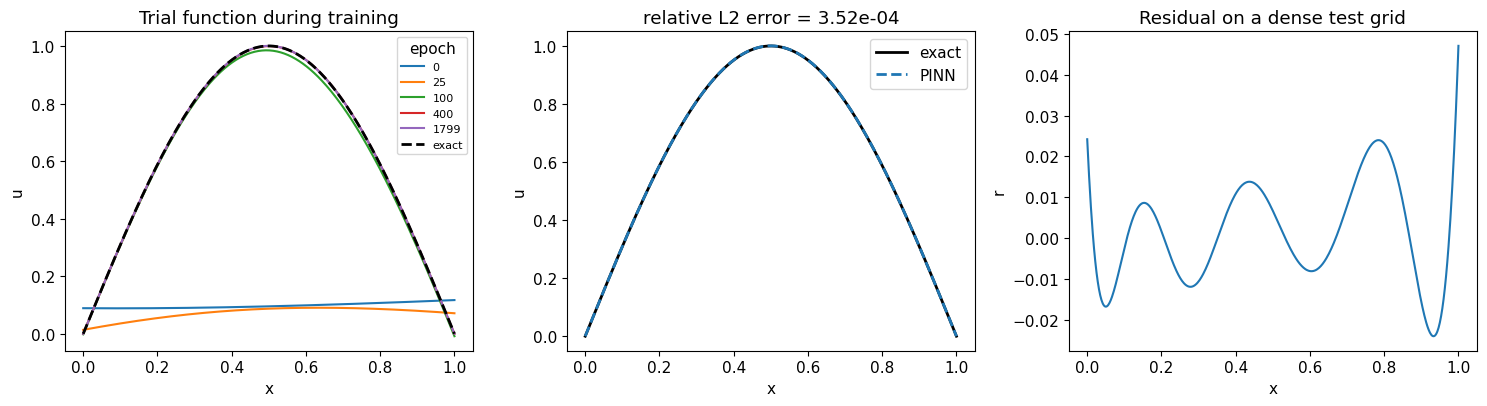

In [18]:
# Compare saved training stages with the exact solution kept out of training.
x_test_p = np.linspace(0, 1, 600)
u_exact_p = np.sin(np.pi*x_test_p)
with torch.no_grad():
    u_pred_p = pinn(to_tensor(x_test_p[:, None])).cpu().numpy().ravel()
r_test_p, _ = poisson_residual(pinn, to_tensor(x_test_p[:, None]))
r_test_p = r_test_p.detach().cpu().numpy().ravel()

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for epoch, values in snapshots.items():
    ax[0].plot(np.linspace(0, 1, 300), values, label=str(epoch))
ax[0].plot(x_test_p, u_exact_p, "k--", lw=2, label="exact")
ax[0].set(title="Trial function during training", xlabel="x", ylabel="u")
ax[0].legend(title="epoch", fontsize=8)
ax[1].plot(x_test_p, u_exact_p, "k", lw=2, label="exact")
ax[1].plot(x_test_p, u_pred_p, "--", lw=2, label="PINN")
ax[1].set(title=f"relative L2 error = {np.linalg.norm(u_pred_p-u_exact_p)/np.linalg.norm(u_exact_p):.2e}",
          xlabel="x", ylabel="u")
ax[1].legend()
ax[2].plot(x_test_p, r_test_p)
ax[2].set(title="Residual on a dense test grid", xlabel="x", ylabel="r")
plt.tight_layout(); plt.show()

The exact analytical solution is more accurate for this stated problem because it has no approximation error. A PINN has finite representation, sampling and optimization errors. A high-resolution conventional solver is also normally faster and more accurate for one known forward problem. PINNs are valuable when equations must be coupled with sparse observations, unknown parameters or repeated differentiable inverse calculations.

## Loss histories and possible PINN failures

The following plot separates equation, boundary and validation losses. A PINN may fail because its network is too small, optimization stalls, loss terms are badly balanced, or collocation points are too sparse.

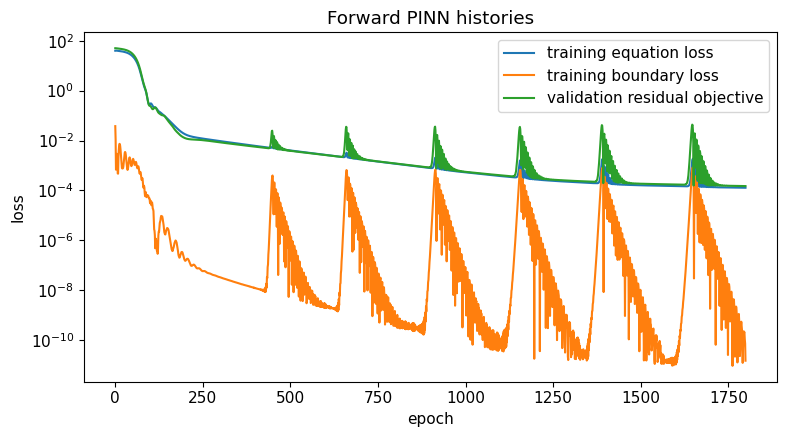

In [19]:
import matplotlib.pyplot as plt
# Plot the PINN loss histories to check how training progressed.
plt.figure(figsize=(8, 4.5))

plt.semilogy(
    history["eq"],
    label="training equation loss"
)

plt.semilogy(
    history["bc"],
    label="training boundary loss"
)

plt.semilogy(
    history["val"],
    label="validation residual objective"
)

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Forward PINN histories")
plt.legend()
plt.tight_layout()
plt.show()

Low training residual but high validation residual indicates overfitting to the collocation points. High training and validation residuals indicate underfitting or stalled optimization. A low differential-equation residual can still select the wrong solution when boundary or initial conditions are missing, because the equation alone may admit multiple solutions.


# Binary diffusion as an inverse PINN

The inverse calculation is developed as a sequence of stages rather than as one large training block.

Two inverse situations are compared:

- the measured composition profile, terminal compositions, governing equation and assumed constitutive family are supplied, but no independent diffusivity measurements are given;
- the same information is supplemented by a few independent diffusivity values.

This makes it possible to distinguish **fitting the concentration profile** from **identifying the constitutive relation** $\widetilde D(c)$.


## Stage — Specify the constitutive family

The synthetic example assumes

$$
\widetilde D(c)=D_{\mathrm{kin}}(c)\Phi(c),
$$

with

$$
D_{\mathrm{kin}}(c)=D_0\exp\left[-\frac{Q(c)}{RT}\right],
\qquad
Q(c)=a_0+a_1c+a_2c^2.
$$

The inverse PINN estimates only the three coefficients in this selected family. This is already strong prior physical information; the profile is not being used to recover an arbitrary function.


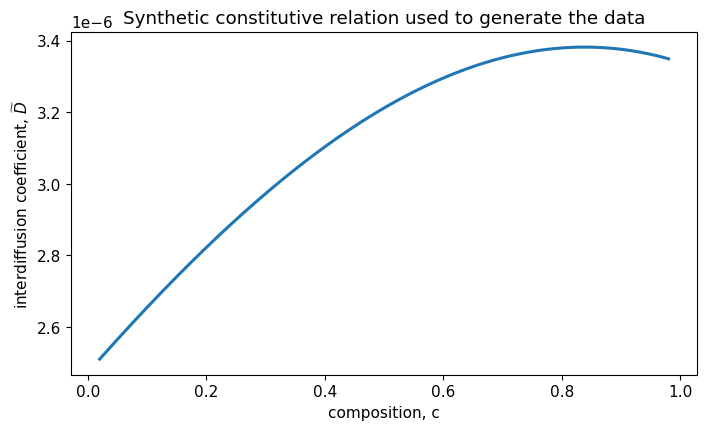

In [20]:
# Synthetic constitutive relation used to generate the example.
R = 8.314
T_const = 1200.0

D0_true = 5.0e-5
Omega_true = -1800.0

# Q(c) = a0 + a1 c + a2 c^2
a_true = np.array([
    30000.0,
    -4000.0,
    1000.0
])


def Q_np(concentration, coefficients):
    return (
        coefficients[0]
        + coefficients[1] * concentration
        + coefficients[2] * concentration**2
    )


def Dkin_np(concentration, coefficients):
    return D0_true * np.exp(
        -Q_np(concentration, coefficients)
        / (R * T_const)
    )


def phi_np(concentration):
    return (
        1.0
        - (
            2.0 * Omega_true
            / (R * T_const)
        )
        * concentration
        * (1.0 - concentration)
    )


def Dtilde_np(concentration, coefficients):
    return (
        Dkin_np(concentration, coefficients)
        * phi_np(concentration)
    )


composition_grid = np.linspace(
    0.02,
    0.98,
    300
)

plt.figure(figsize=(7.2, 4.6))

plt.plot(
    composition_grid,
    Dtilde_np(
        composition_grid,
        a_true
    ),
    linewidth=2.2
)

plt.xlabel("composition, c")
plt.ylabel(r"interdiffusion coefficient, $\widetilde D$")
plt.title("Synthetic constitutive relation used to generate the data")
plt.tight_layout()
plt.show()


The complete diffusivity curve is visible here only because the example is synthetic. During inversion it should be regarded as hidden and revealed only for diagnostic comparison.


## Stage — Generate the measured composition profile

A conservative finite-volume update generates a diffusion-couple profile. The latest profile is then treated as a synthetic experimental measurement.


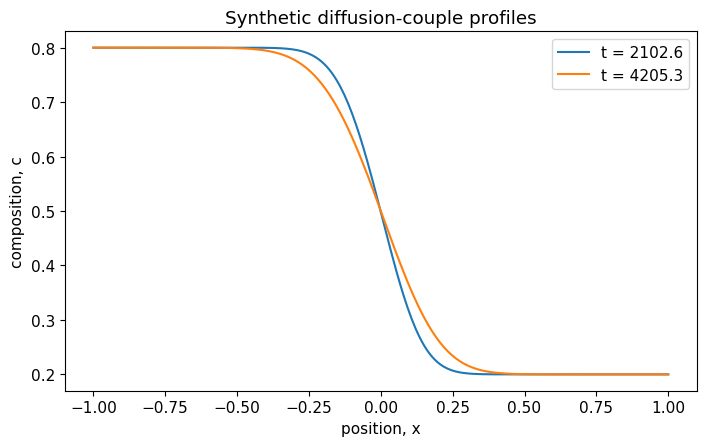

In [21]:
# Generate a synthetic diffusion-couple profile.
domain_length = 2.0
number_of_points = 301

x_diff = np.linspace(
    -domain_length / 2.0,
    domain_length / 2.0,
    number_of_points
)

dx = x_diff[1] - x_diff[0]

cL = 0.80
cR = 0.20

concentration = np.where(
    x_diff < 0.0,
    cL,
    cR
).astype(float)

maximum_diffusivity = np.max(
    Dtilde_np(
        np.linspace(0.0, 1.0, 300),
        a_true
    )
)

dt = (
    0.08
    * dx**2
    / maximum_diffusivity
)

profiles = {}

for step in range(1, 4001):

    diffusivity = Dtilde_np(
        concentration,
        a_true
    )

    concentration_padded = np.pad(
        concentration,
        1,
        mode="edge"
    )

    diffusivity_padded = np.pad(
        diffusivity,
        1,
        mode="edge"
    )

    concentration_gradient_half = (
        concentration_padded[1:]
        - concentration_padded[:-1]
    ) / dx

    flux_half = (
        -0.5
        * (
            diffusivity_padded[1:]
            + diffusivity_padded[:-1]
        )
        * concentration_gradient_half
    )

    concentration += (
        -dt
        * (
            flux_half[1:]
            - flux_half[:-1]
        )
        / dx
    )

    concentration = np.clip(
        concentration,
        1.0e-7,
        1.0 - 1.0e-7
    )

    if step in (2000, 4000):
        profiles[step * dt] = concentration.copy()


plt.figure(figsize=(7.2, 4.6))

for profile_time, profile_values in profiles.items():
    plt.plot(
        x_diff,
        profile_values,
        label=f"t = {profile_time:.1f}"
    )

plt.xlabel("position, x")
plt.ylabel("composition, c")
plt.title("Synthetic diffusion-couple profiles")
plt.legend()
plt.tight_layout()
plt.show()


In an experiment, position and time units must be mutually consistent because $\widetilde D$ has units of length squared per time.


## Stage — Transform to the Boltzmann coordinate

For Boltzmann similarity,

$$
\lambda=\frac{x-x_M}{\sqrt{t}},
\qquad
c(x,t)=c(\lambda),
$$

and the diffusion equation becomes

$$
-\frac{\lambda}{2}\frac{dc}{d\lambda}
=
\frac{d}{d\lambda}
\left[
\widetilde D(c)\frac{dc}{d\lambda}
\right].
$$

The neural network receives the scaled coordinate $z=\lambda/\lambda_{\mathrm{scale}}$.


In [22]:
# Use the latest synthetic profile.
t_latest = max(profiles)
c_latest = profiles[t_latest]

# Locate the Matano plane from mass balance.
sort_by_composition = np.argsort(c_latest)

composition_sorted = c_latest[
    sort_by_composition
]

position_sorted = x_diff[
    sort_by_composition
]

x_M = (
    np.sum(
        0.5
        * (
            position_sorted[:-1]
            + position_sorted[1:]
        )
        * np.diff(composition_sorted)
    )
    / np.sum(
        np.diff(composition_sorted)
    )
)

# Form and scale the Boltzmann coordinate.
lam = (
    x_diff
    - x_M
) / np.sqrt(t_latest)

lam_scale = np.max(
    np.abs(lam)
)

lam_hat = lam / lam_scale

print(f"Matano plane = {x_M:.6f}")
print(f"lambda scale = {lam_scale:.6e}")


Matano plane = -0.003333
lambda scale = 1.547203e-02


Alternating profile points are used for fitting and interpolation checking. This is not a strong independent validation of the inferred diffusivity; additional diffusion times, couples or direct diffusivity measurements would be more informative.


In [23]:
# Alternate points for profile fitting and interpolation checks.
profile_train = (
    np.arange(number_of_points) % 2 == 0
)

profile_val = ~profile_train

Xprof = to_tensor(
    lam_hat[
        profile_train,
        None
    ]
)

yprof = to_tensor(
    c_latest[
        profile_train,
        None
    ]
)

Xprof_v = to_tensor(
    lam_hat[
        profile_val,
        None
    ]
)

yprof_v = to_tensor(
    c_latest[
        profile_val,
        None
    ]
)

# Terminal compositions.
Xbc = to_tensor([
    [lam_hat.min()],
    [lam_hat.max()]
])

ybc = to_tensor([
    [cL],
    [cR]
])

# Collocation points for the governing-equation residual.
Xf = to_tensor(
    np.linspace(
        lam_hat.min(),
        lam_hat.max(),
        350
    )[:, None]
)

print("Profile fitting points:", len(Xprof))
print("Interpolation-check points:", len(Xprof_v))
print("Physics collocation points:", len(Xf))


Profile fitting points: 151
Interpolation-check points: 150
Physics collocation points: 350


## Stage — Build the profile and constitutive model

`BinaryInversePINN` contains two fitted objects:

- a neural representation of the concentration profile $c_\theta(z)$;
- three trainable coefficients defining $Q(c)$ and therefore $\widetilde D(c)$.

A good fit of $c(z)$ does not automatically imply that the constitutive coefficients have been identified.


In [24]:
class BinaryInversePINN(nn.Module):
    """Inverse PINN for a binary diffusion couple."""

    def __init__(self):
        super().__init__()

        # Neural representation of the concentration profile c(z).
        self.profile = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

        # Scaled trainable coefficients for Q(c).
        self.alpha0 = nn.Parameter(
            torch.tensor(
                2.8,
                dtype=torch.float32
            )
        )

        self.alpha1 = nn.Parameter(
            torch.tensor(
                -0.25,
                dtype=torch.float32
            )
        )

        self.alpha2 = nn.Parameter(
            torch.tensor(
                0.8,
                dtype=torch.float32
            )
        )

    def forward(self, z):
        return torch.sigmoid(
            self.profile(z)
        )

    def Q(self, concentration):
        return (
            1.0e4 * self.alpha0
            + 1.0e4 * self.alpha1 * concentration
            + 1.0e3 * self.alpha2 * concentration**2
        )

    def Dkin(self, concentration):
        return (
            D0_true
            * torch.exp(
                -self.Q(concentration)
                / (R * T_const)
            )
        )

    def thermodynamic_factor(
        self,
        concentration
    ):
        return (
            1.0
            - (
                2.0 * Omega_true
                / (R * T_const)
            )
            * concentration
            * (1.0 - concentration)
        )

    def Dtilde(self, concentration):
        return (
            self.Dkin(concentration)
            * self.thermodynamic_factor(
                concentration
            )
        )


The profile network has architecture

$$
1\rightarrow32\rightarrow32\rightarrow32\rightarrow1.
$$

Its hidden neurons are adjustable mathematical features, not separate physical variables.


## Stage — Write the Boltzmann diffusion residual

Because $z=\lambda/\lambda_{\mathrm{scale}}$,

$$
\frac{dc}{d\lambda}
=
\frac{1}{\lambda_{\mathrm{scale}}}\frac{dc}{dz}.
$$

Automatic differentiation evaluates the transformed governing-equation residual.


In [25]:
def binary_residual(
    model,
    z_points
):
    """Evaluate the Boltzmann diffusion residual."""

    # A fresh differentiable coordinate is required for autograd.
    z = (
        z_points
        .detach()
        .clone()
        .requires_grad_(True)
    )

    concentration = model(z)

    dc_dz = torch.autograd.grad(
        outputs=concentration,
        inputs=z,
        grad_outputs=torch.ones_like(
            concentration
        ),
        create_graph=True
    )[0]

    dc_dlambda = (
        dc_dz
        / lam_scale
    )

    flux_term = (
        model.Dtilde(concentration)
        * dc_dlambda
    )

    dflux_dz = torch.autograd.grad(
        outputs=flux_term,
        inputs=z,
        grad_outputs=torch.ones_like(
            flux_term
        ),
        create_graph=True
    )[0]

    dflux_dlambda = (
        dflux_dz
        / lam_scale
    )

    lambda_physical = (
        z
        * lam_scale
    )

    residual = (
        -0.5
        * lambda_physical
        * dc_dlambda
        - dflux_dlambda
    )

    return residual, concentration


The residual is zero only when the predicted profile and predicted diffusivity satisfy the Boltzmann-transformed diffusion equation together.


## Stage — Fit the measured composition profile

The profile network is first trained only against the composition measurements and terminal compositions.

Only `profile.parameters()` are passed to the optimizer, so the constitutive coefficients remain fixed during this stage.


In [26]:
torch.manual_seed(SEED)

profile_seed_model = BinaryInversePINN().to(
    device
)

profile_optimizer = torch.optim.Adam(
    profile_seed_model.profile.parameters(),
    lr=1.0e-3
)

profile_pretraining_history = []

for epoch in range(700):

    profile_optimizer.zero_grad()

    boundary_loss = torch.mean(
        (
            profile_seed_model(Xbc)
            - ybc
        )**2
    )

    profile_loss = torch.mean(
        (
            profile_seed_model(Xprof)
            - yprof
        )**2
    )

    pretraining_loss = (
        20.0 * boundary_loss
        + 100.0 * profile_loss
    )

    pretraining_loss.backward()
    profile_optimizer.step()

    profile_pretraining_history.append(
        float(
            pretraining_loss
            .detach()
            .cpu()
        )
    )

print(
    "Final profile-pretraining loss:",
    f"{profile_pretraining_history[-1]:.3e}"
)


Final profile-pretraining loss: 1.453e-03


A close fit to the composition profile has now been obtained, but no constitutive inference has yet occurred.

> A fitted composition profile is not, by itself, a diffusivity measurement.


Coefficients after profile fitting:
a0 = 28000.00
a1 = -2500.00
a2 = 800.00


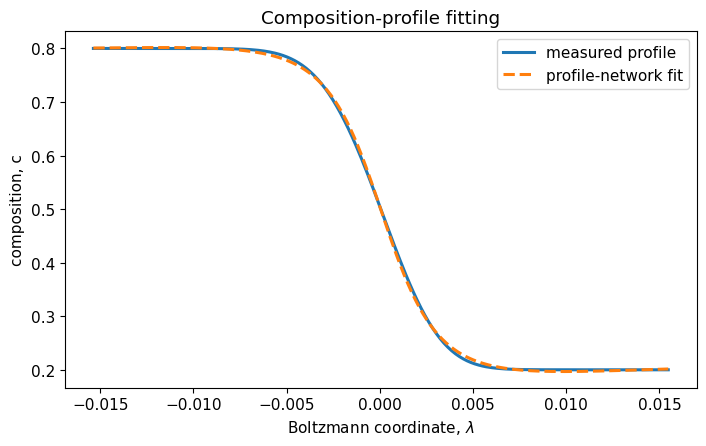

In [27]:
# Confirm that profile fitting did not update Q(c).
print("Coefficients after profile fitting:")

print(
    f"a0 = {1.0e4 * profile_seed_model.alpha0.item():.2f}"
)

print(
    f"a1 = {1.0e4 * profile_seed_model.alpha1.item():.2f}"
)

print(
    f"a2 = {1.0e3 * profile_seed_model.alpha2.item():.2f}"
)

with torch.no_grad():

    profile_seed_prediction = (
        profile_seed_model(
            to_tensor(
                lam_hat[:, None]
            )
        )
        .cpu()
        .numpy()
        .ravel()
    )

plt.figure(figsize=(7.2, 4.6))

plt.plot(
    lam,
    c_latest,
    linewidth=2.2,
    label="measured profile"
)

plt.plot(
    lam,
    profile_seed_prediction,
    "--",
    linewidth=2.2,
    label="profile-network fit"
)

plt.xlabel(
    r"Boltzmann coordinate, $\lambda$"
)
plt.ylabel("composition, c")
plt.title("Composition-profile fitting")
plt.legend()
plt.tight_layout()
plt.show()


## Stage — Define the inverse information

Every inverse run uses:

- the measured composition profile;
- terminal compositions;
- the Boltzmann diffusion residual.

Sparse diffusivity measurements are optional. When supplied, their mismatch is measured in logarithmic space because diffusivities are naturally compared through relative errors.


In [28]:
def inverse_loss_components(
    model,
    x_collocation,
    x_profile,
    y_profile,
    x_boundary,
    y_boundary,
    diffusivity_compositions=None,
    diffusivity_values=None
):
    # Governing-equation residual.
    residual, _ = binary_residual(
        model,
        x_collocation
    )

    physics_loss = torch.mean(
        residual**2
    )

    # Terminal-composition mismatch.
    boundary_loss = torch.mean(
        (
            model(x_boundary)
            - y_boundary
        )**2
    )

    # Measured-profile mismatch.
    profile_loss = torch.mean(
        (
            model(x_profile)
            - y_profile
        )**2
    )

    # Optional sparse diffusivity data.
    if diffusivity_compositions is None:

        diffusivity_data_loss = torch.zeros(
            (),
            dtype=torch.float32,
            device=device
        )

    else:

        tiny = torch.finfo(
            torch.float32
        ).tiny

        predicted_diffusivity = model.Dtilde(
            diffusivity_compositions
        )

        diffusivity_data_loss = torch.mean(
            (
                torch.log(
                    torch.clamp(
                        predicted_diffusivity,
                        min=tiny
                    )
                )
                - torch.log(
                    diffusivity_values
                )
            )**2
        )

    return {
        "physics": physics_loss,
        "boundary": boundary_loss,
        "profile": profile_loss,
        "diffusivity_data": diffusivity_data_loss
    }


def assemble_inverse_loss(
    components
):
    return (
        components["physics"]
        + 20.0 * components["boundary"]
        + 100.0 * components["profile"]
        + 20.0 * components["diffusivity_data"]
    )


The loss weights are numerical optimization choices. They are not material constants and they do not add new physics.


## Stage — Use the same training loop for both inverse situations

The optimizer and training procedure are identical in both cases. The only difference is whether sparse diffusivity values are passed to the loss.


In [29]:
def train_inverse_model(
    model,
    epochs,
    diffusivity_compositions=None,
    diffusivity_values=None
):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1.0e-3
    )

    history = {
        key: []
        for key in [
            "total",
            "physics",
            "boundary",
            "profile",
            "diffusivity_data",
            "validation_profile",
            "a0",
            "a1",
            "a2"
        ]
    }

    for epoch in range(epochs):

        optimizer.zero_grad()

        components = inverse_loss_components(
            model=model,
            x_collocation=Xf,
            x_profile=Xprof,
            y_profile=yprof,
            x_boundary=Xbc,
            y_boundary=ybc,
            diffusivity_compositions=diffusivity_compositions,
            diffusivity_values=diffusivity_values
        )

        total_loss = assemble_inverse_loss(
            components
        )

        total_loss.backward()
        optimizer.step()

        history["total"].append(
            float(
                total_loss
                .detach()
                .cpu()
            )
        )

        for key in [
            "physics",
            "boundary",
            "profile",
            "diffusivity_data"
        ]:
            history[key].append(
                float(
                    components[key]
                    .detach()
                    .cpu()
                )
            )

        with torch.no_grad():

            validation_profile_loss = torch.mean(
                (
                    model(Xprof_v)
                    - yprof_v
                )**2
            )

        history["validation_profile"].append(
            float(
                validation_profile_loss
                .detach()
                .cpu()
            )
        )

        history["a0"].append(
            float(
                (
                    1.0e4
                    * model.alpha0
                )
                .detach()
                .cpu()
            )
        )

        history["a1"].append(
            float(
                (
                    1.0e4
                    * model.alpha1
                )
                .detach()
                .cpu()
            )
        )

        history["a2"].append(
            float(
                (
                    1.0e3
                    * model.alpha2
                )
                .detach()
                .cpu()
            )
        )

    return history


## Stage — Estimate diffusivity from the profile and physics only

The first inverse model receives no independent diffusivity values.

It is supplied with one composition profile, terminal compositions, the governing equation and the assumed Arrhenius–quadratic constitutive family. This is more informative than curve fitting alone, but several constitutive parameter combinations may still produce very similar profiles.


In [30]:
# Start both inverse situations from the same profile-fitted state.
profile_only_model = copy.deepcopy(
    profile_seed_model
)

sparse_data_model = copy.deepcopy(
    profile_seed_model
)

history_profile_only = train_inverse_model(
    model=profile_only_model,
    epochs=1600
)

print(
    "Profile-and-physics-only coefficients:"
)

print(
    f"a0 = {history_profile_only['a0'][-1]:.2f}"
)

print(
    f"a1 = {history_profile_only['a1'][-1]:.2f}"
)

print(
    f"a2 = {history_profile_only['a2'][-1]:.2f}"
)


Profile-and-physics-only coefficients:
a0 = 29701.87
a1 = -3130.12
a2 = 421.58


The profile-only inverse model should now reproduce the measured profile and satisfy the diffusion equation reasonably well. The remaining question is whether the inferred constitutive relation is uniquely and accurately determined.


In [31]:
def evaluate_inverse_model(
    model
):
    with torch.no_grad():

        profile_prediction = (
            model(
                to_tensor(
                    lam_hat[:, None]
                )
            )
            .cpu()
            .numpy()
            .ravel()
        )

        diffusivity_prediction = (
            model.Dtilde(
                to_tensor(
                    composition_grid[:, None]
                )
            )
            .cpu()
            .numpy()
            .ravel()
        )

    profile_rmse = rmse(
        c_latest,
        profile_prediction
    )

    true_diffusivity = Dtilde_np(
        composition_grid,
        a_true
    )

    relative_diffusivity_error = (
        np.linalg.norm(
            diffusivity_prediction
            - true_diffusivity
        )
        / np.linalg.norm(
            true_diffusivity
        )
    )

    return {
        "profile": profile_prediction,
        "diffusivity": diffusivity_prediction,
        "profile_rmse": profile_rmse,
        "relative_diffusivity_error":
            relative_diffusivity_error
    }


profile_only_results = evaluate_inverse_model(
    profile_only_model
)

print(
    "Profile-only profile RMSE:",
    f"{profile_only_results['profile_rmse']:.3e}"
)

print(
    "Profile-only relative diffusivity error:",
    f"{profile_only_results['relative_diffusivity_error']:.3e}"
)


Profile-only profile RMSE: 1.244e-04
Profile-only relative diffusivity error: 9.156e-03


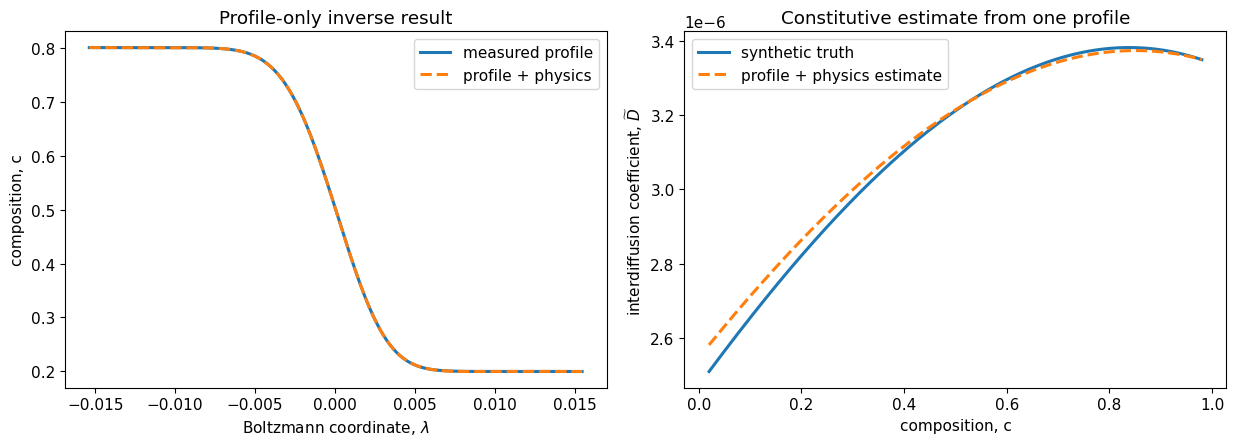

In [32]:
# The full synthetic truth is revealed only for diagnosis.
true_diffusivity_curve = Dtilde_np(
    composition_grid,
    a_true
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12.5, 4.6)
)

axes[0].plot(
    lam,
    c_latest,
    linewidth=2.2,
    label="measured profile"
)

axes[0].plot(
    lam,
    profile_only_results["profile"],
    "--",
    linewidth=2.2,
    label="profile + physics"
)

axes[0].set_xlabel(
    r"Boltzmann coordinate, $\lambda$"
)
axes[0].set_ylabel("composition, c")
axes[0].set_title("Profile-only inverse result")
axes[0].legend()


axes[1].plot(
    composition_grid,
    true_diffusivity_curve,
    linewidth=2.2,
    label="synthetic truth"
)

axes[1].plot(
    composition_grid,
    profile_only_results["diffusivity"],
    "--",
    linewidth=2.2,
    label="profile + physics estimate"
)

axes[1].set_xlabel("composition, c")
axes[1].set_ylabel(
    r"interdiffusion coefficient, $\widetilde D$"
)
axes[1].set_title(
    "Constitutive estimate from one profile"
)
axes[1].legend()

plt.tight_layout()
plt.show()


A composition profile can be reproduced accurately even when the constitutive coefficients remain weakly identified. The profile is an integrated consequence of diffusivity over composition and time; it is not a direct pointwise measurement of $\widetilde D(c)$.


## Stage — Add a few independent diffusivity measurements

Now three independent interdiffusion coefficients are supplied at selected compositions.

The measured profile, governing equation and constitutive family remain unchanged. Only the information content of the inverse problem changes.


In [33]:
# Three sparse independent diffusivity measurements.
sparse_composition_np = np.array([
    0.25,
    0.50,
    0.75
])

sparse_diffusivity_np = Dtilde_np(
    sparse_composition_np,
    a_true
)

Xdiff_sparse = to_tensor(
    sparse_composition_np[:, None]
)

ydiff_sparse = to_tensor(
    sparse_diffusivity_np[:, None]
)

print("Sparse diffusivity information:")

for composition_value, diffusivity_value in zip(
    sparse_composition_np,
    sparse_diffusivity_np
):
    print(
        f"c = {composition_value:.2f}, "
        f"D_tilde = {diffusivity_value:.4e}"
    )


Sparse diffusivity information:
c = 0.25, D_tilde = 2.8993e-06
c = 0.50, D_tilde = 3.2118e-06
c = 0.75, D_tilde = 3.3697e-06


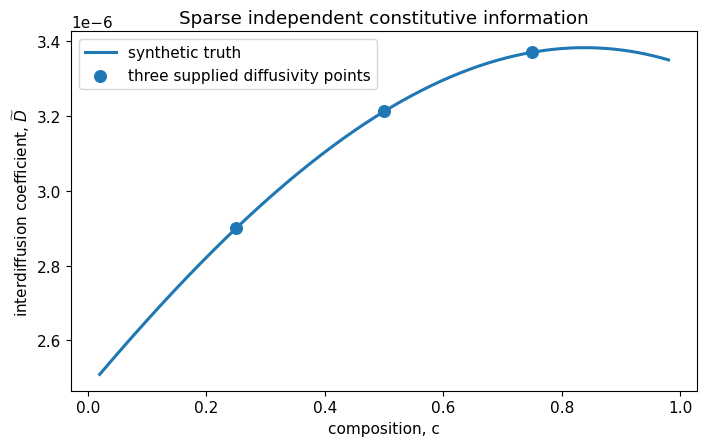

In [34]:
plt.figure(figsize=(7.2, 4.6))

plt.plot(
    composition_grid,
    true_diffusivity_curve,
    linewidth=2.2,
    label="synthetic truth"
)

plt.scatter(
    sparse_composition_np,
    sparse_diffusivity_np,
    s=70,
    marker="o",
    label="three supplied diffusivity points"
)

plt.xlabel("composition, c")
plt.ylabel(
    r"interdiffusion coefficient, $\widetilde D$"
)
plt.title("Sparse independent constitutive information")
plt.legend()
plt.tight_layout()
plt.show()


In a real application the complete curve would not be visible. Only these few measured values, their uncertainties and the assumed constitutive family would be available.


## Stage — Refit with profile, physics and sparse diffusivity data

For a fair comparison, this model starts from exactly the same profile-fitted state as the profile-only model. The sparse diffusivity values enter only through the additional log-space data loss.


In [35]:
history_sparse_data = train_inverse_model(
    model=sparse_data_model,
    epochs=1600,
    diffusivity_compositions=Xdiff_sparse,
    diffusivity_values=ydiff_sparse
)

print(
    "Profile-plus-sparse-data coefficients:"
)

print(
    f"a0 = {history_sparse_data['a0'][-1]:.2f}"
)

print(
    f"a1 = {history_sparse_data['a1'][-1]:.2f}"
)

print(
    f"a2 = {history_sparse_data['a2'][-1]:.2f}"
)


Profile-plus-sparse-data coefficients:
a0 = 29887.00
a1 = -3480.38
a2 = 495.01


The added measurements constrain the local magnitude and composition dependence of $\widetilde D(c)$. They do not guarantee uniqueness, but they reduce the range of constitutive curves compatible with the same composition profile.


## Stage — Compare the two inverse situations

Both models have seen the same composition profile and the same governing equation. Their only difference is the presence or absence of three independent diffusivity measurements.


In [36]:
sparse_data_results = evaluate_inverse_model(
    sparse_data_model
)

print("Profile and physics only")

print(
    "  profile RMSE = "
    f"{profile_only_results['profile_rmse']:.3e}"
)

print(
    "  relative diffusivity error = "
    f"{profile_only_results['relative_diffusivity_error']:.3e}"
)

print()

print(
    "Profile, physics and three diffusivity points"
)

print(
    "  profile RMSE = "
    f"{sparse_data_results['profile_rmse']:.3e}"
)

print(
    "  relative diffusivity error = "
    f"{sparse_data_results['relative_diffusivity_error']:.3e}"
)


Profile and physics only
  profile RMSE = 1.244e-04
  relative diffusivity error = 9.156e-03

Profile, physics and three diffusivity points
  profile RMSE = 1.564e-04
  relative diffusivity error = 3.784e-03


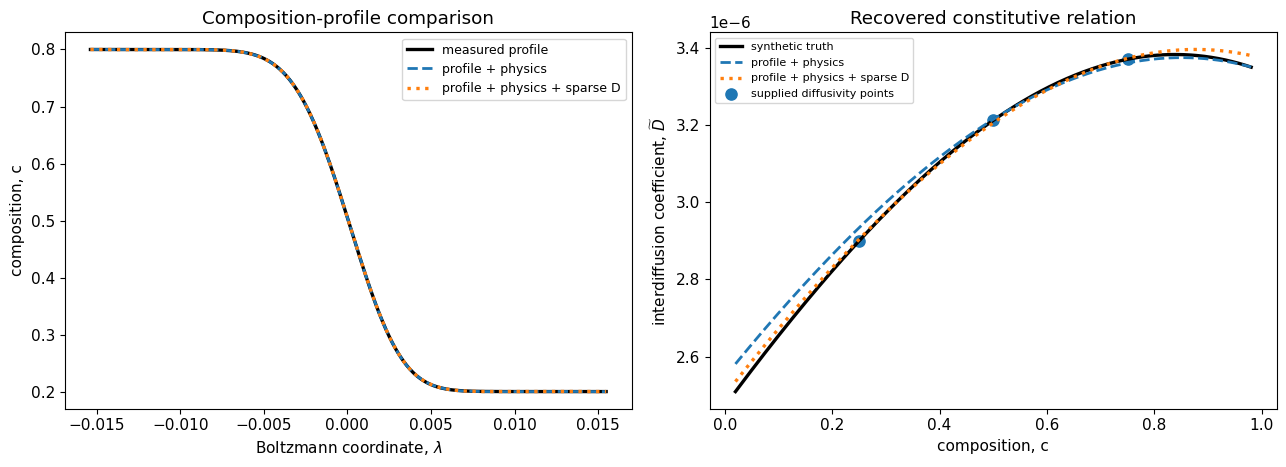

In [37]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13.0, 4.8)
)

# Both models reproduce the same measured profile.
axes[0].plot(
    lam,
    c_latest,
    color="black",
    linewidth=2.4,
    label="measured profile"
)

axes[0].plot(
    lam,
    profile_only_results["profile"],
    "--",
    linewidth=2.0,
    label="profile + physics"
)

axes[0].plot(
    lam,
    sparse_data_results["profile"],
    ":",
    linewidth=2.4,
    label="profile + physics + sparse D"
)

axes[0].set_xlabel(
    r"Boltzmann coordinate, $\lambda$"
)
axes[0].set_ylabel("composition, c")
axes[0].set_title("Composition-profile comparison")
axes[0].legend(fontsize=9)


# The constitutive estimates are distinguished here.
axes[1].plot(
    composition_grid,
    true_diffusivity_curve,
    color="black",
    linewidth=2.4,
    label="synthetic truth"
)

axes[1].plot(
    composition_grid,
    profile_only_results["diffusivity"],
    "--",
    linewidth=2.0,
    label="profile + physics"
)

axes[1].plot(
    composition_grid,
    sparse_data_results["diffusivity"],
    ":",
    linewidth=2.4,
    label="profile + physics + sparse D"
)

axes[1].scatter(
    sparse_composition_np,
    sparse_diffusivity_np,
    s=65,
    marker="o",
    label="supplied diffusivity points"
)

axes[1].set_xlabel("composition, c")
axes[1].set_ylabel(
    r"interdiffusion coefficient, $\widetilde D$"
)
axes[1].set_title("Recovered constitutive relation")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


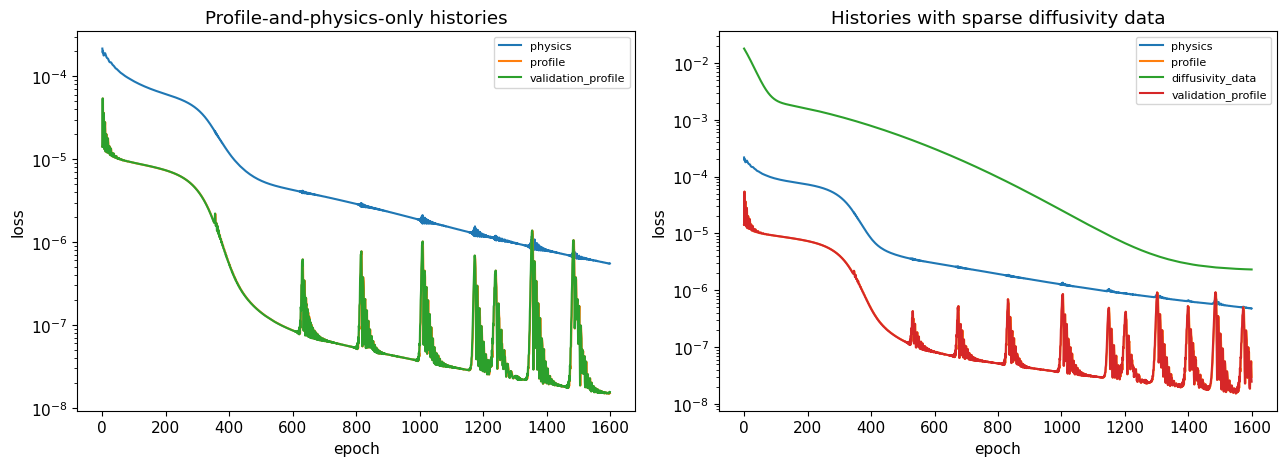

In [38]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13.0, 4.8)
)

for key in [
    "physics",
    "profile",
    "validation_profile"
]:
    axes[0].semilogy(
        history_profile_only[key],
        label=key
    )

axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title(
    "Profile-and-physics-only histories"
)
axes[0].legend(fontsize=8)


for key in [
    "physics",
    "profile",
    "diffusivity_data",
    "validation_profile"
]:
    axes[1].semilogy(
        history_sparse_data[key],
        label=key
    )

axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title(
    "Histories with sparse diffusivity data"
)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


The important comparison is not simply which model gives the lower total loss.

Both inverse models can reproduce the composition profile well. The sparse diffusivity values add local constitutive information that one integrated profile does not provide strongly.

- **Profile plus physics:** estimates a diffusivity relation within the assumed family, but the result may remain weakly identifiable.
- **Profile plus physics plus sparse diffusivity data:** constrains the constitutive relation more directly and generally improves recoverability.
- **Neither case proves uniqueness:** additional diffusion times, additional couples, uncertainty analysis and independent experiments remain important.

A low profile error shows that the concentration field has been reproduced. It does not, by itself, prove that the underlying diffusivity has been uniquely identified.


In [39]:
# Preserve variable names used by later notebook checks.
inv_model = sparse_data_model
history_inv = history_sparse_data

concentration_prediction = (
    sparse_data_results["profile"]
)

diffusivity_prediction = (
    sparse_data_results["diffusivity"]
)

profile_error = (
    sparse_data_results["profile_rmse"]
)

relative_diffusivity_error = (
    sparse_data_results[
        "relative_diffusivity_error"
    ]
)



# Part V — Fourier Neural Operator: Learn a Map Between Fields

## From one solution to a family of solutions

Earlier, a neural network was used to learn one particular solution of a differential equation. In operator learning, the aim is broader: we want one trained model that can solve an entire family of related problems.

Consider the boundary-value problem

$$
-u''(x)=f(x),
\qquad
0<x<1,
$$

with boundary conditions

$$
u(0)=0,
\qquad
u(1)=0.
$$

Here, $f(x)$ is the source term and $u(x)$ is the corresponding solution.

For one fixed source function $f(x)$, solving the equation gives one solution function $u(x)$. If the source function changes, the solution also changes.

For example,

$$
f_1(x)
\longrightarrow
u_1(x),
$$

$$
f_2(x)
\longrightarrow
u_2(x),
$$

and

$$
f_3(x)
\longrightarrow
u_3(x).
$$

The mathematical rule that maps each complete source function to its complete solution function is called a **solution operator**.

We write this as

$$
\mathcal{G}:f(\cdot)\mapsto u(\cdot).
$$

The notation $f(\cdot)$ emphasizes that the input is an entire function, not a single number. Similarly, $u(\cdot)$ is an entire output function.

For the Poisson equation, the operator $\mathcal{G}$ means:

$$
u=\mathcal{G}(f).
$$

Thus, the operator takes the full field $f(x)$ and returns the full field $u(x)$.

## Function learning and operator learning

In ordinary function learning, a neural network may learn a relation such as

$$
x\mapsto y.
$$

The input is usually a finite list of numbers, and the output is another number or a finite list of numbers.

In operator learning, the mapping is

$$
f(x)\mapsto u(x).
$$

Both the input and output are functions or fields.

After discretization on grid points $x_1,\ldots,x_N$, the input field is represented by

$$
\mathbf{f}
=
\begin{bmatrix}
f(x_1)\\
f(x_2)\\
\vdots\\
f(x_N)
\end{bmatrix},
$$

and the output field is represented by

$$
\mathbf{u}
=
\begin{bmatrix}
u(x_1)\\
u(x_2)\\
\vdots\\
u(x_N)
\end{bmatrix}.
$$

The neural operator therefore learns a mapping from one discretized field to another:

$$
\mathbf{f}\mapsto\mathbf{u}.
$$

However, the underlying goal is still to approximate the continuous operator

$$
\mathcal{G}:f(\cdot)\mapsto u(\cdot).
$$

## Why learn an operator?

A conventional numerical solver solves the differential equation separately for every new source function.

For each new $f(x)$, it must again assemble and solve the discretized equations.

An operator model is trained using many input-output pairs:

$$
\left\{
f^{(j)}(x),
u^{(j)}(x)
\right\}_{j=1}^{N_{\mathrm{train}}}.
$$

After training, the model can predict the solution for a new source function:

$$
f_{\mathrm{new}}(x)
\longrightarrow
u_{\mathrm{pred}}(x).
$$

The expensive work is moved to the training stage. Prediction for a new input field can then be much faster.

This is useful when the same class of differential equations must be solved many times, such as in

- parameter studies,
- uncertainty analysis,
- optimization,
- inverse problems,
- real-time prediction,
- and digital twins.

## Fourier representation of a field

A field can be described in physical space by its values at different positions. The same field can also be described as a combination of spatial waves.

For a periodic function, a Fourier representation has the form

$$
f(x)
=
\sum_{k}
\widehat{f}_k
e^{2\pi i kx}.
$$

Here,

- $k$ is the wave number,
- $e^{2\pi i kx}$ is a spatial wave,
- $\widehat{f}_k$ is the amplitude of that wave.

Each value of $k$ corresponds to one **Fourier mode**.

Low Fourier modes vary slowly in space and describe broad features of the field.

High Fourier modes vary rapidly in space and describe fine details.

For example:

- a low mode may represent the overall shape of a concentration profile,
- a high mode may represent sharp local variations or small-scale oscillations.

The Fourier transform converts the field from physical space to Fourier space:

$$
f(x)
\quad
\longrightarrow
\quad
\widehat{f}_k.
$$

The inverse Fourier transform reconstructs the field:

$$
\widehat{f}_k
\quad
\longrightarrow
\quad
f(x).
$$

## Main idea of the Fourier Neural Operator

The Fourier Neural Operator, abbreviated as **FNO**, learns how to transform one field into another by working partly in Fourier space.

A typical FNO layer performs the following steps:

1. Transform the current field from physical space to Fourier space.
2. Multiply selected Fourier modes by trainable weights.
3. Transform the result back to physical space.
4. Add a local linear transformation.
5. Apply a nonlinear activation function.

In symbolic form, one FNO layer may be written as

$$
v_{l+1}(x)
=
\sigma
\left[
Wv_l(x)
+
\mathcal{F}^{-1}
\left(
R_l(k)\,
\mathcal{F}[v_l](k)
\right)
\right].
$$

Here,

- $v_l(x)$ is the field entering layer $l$,
- $\mathcal{F}$ is the Fourier transform,
- $\mathcal{F}^{-1}$ is the inverse Fourier transform,
- $R_l(k)$ contains trainable weights for the retained Fourier modes,
- $W$ is a learned local linear transformation,
- $\sigma$ is a nonlinear activation function.

The Fourier part allows information at one position to influence distant positions. This is important because solutions of differential equations often depend on the input field over the whole domain.

## Why only some Fourier modes are retained

In many physical fields, most of the large-scale behavior is contained in the lower Fourier modes.

FNO commonly keeps only a chosen number of low modes and discards the higher modes.

If the number of retained modes is $m$, then the model uses

$$
k=0,1,\ldots,m-1.
$$

Keeping fewer modes reduces the number of trainable parameters and the computational cost.

However, too few modes may remove important fine-scale information. Too many modes increase cost and may make the model more sensitive to noise.

The number of retained modes is therefore a model choice.

## Input and output of the FNO in this example

For each training problem, the input is the discretized source field

$$
f(x_i),
\qquad
i=1,\ldots,N.
$$

The output is the corresponding discretized solution field

$$
u(x_i),
\qquad
i=1,\ldots,N.
$$

The FNO is trained using many pairs of the form

$$
f^{(j)}(x_i)
\longrightarrow
u^{(j)}(x_i).
$$

After training, it receives a new source field sampled on the grid and predicts the entire solution field in one forward pass.

## FNO is not automatically physics-informed

A standard FNO is usually trained using paired input-output data.

Its loss may be

$$
L_{\mathrm{data}}
=
\frac{1}{N_{\mathrm{train}}}
\sum_{j=1}^{N_{\mathrm{train}}}
\left\|
u_{\mathrm{pred}}^{(j)}
-
u_{\mathrm{true}}^{(j)}
\right\|_2^2.
$$

This loss compares the predicted solution with a known reference solution.

The governing equation does not necessarily appear in the loss. Therefore, a standard FNO is an operator-learning model, but it is not automatically physics-informed.

An FNO becomes physics-informed only when physical information is included explicitly. For example, one may add

- the differential-equation residual,
- boundary-condition errors,
- conservation laws,
- symmetry constraints,
- or known constitutive relations.

A physics-informed operator loss may have the form

$$
L
=
L_{\mathrm{data}}
+
\lambda_{\mathrm{eq}}L_{\mathrm{eq}}
+
\lambda_{\mathrm{bc}}L_{\mathrm{bc}}.
$$

Thus,

$$
\text{FNO}
\neq
\text{physics-informed by default}.
$$

The architecture and the training loss are separate choices.

## FNO and PINO

A **Physics-Informed Neural Operator**, abbreviated as **PINO**, combines operator learning with physical constraints.

An FNO may be used as the operator architecture, while the governing equation is added to the training loss.

Therefore, one possible relationship is

$$
\text{PINO}
=
\text{neural operator architecture}
+
\text{physics-based loss}.
$$

In this notebook:

- the FNO section learns the map $f(\cdot)\mapsto u(\cdot)$ mainly from paired data;
- the PINO section adds the Poisson-equation residual and boundary conditions to the operator training.

The key distinction is:

$$
\text{PINN learns one or a few solutions},
$$

whereas

$$
\text{FNO or PINO learns a family of solution maps}.
$$


## Generate exact field-to-field pairs

Random forcing fields are sums of sine waves. Their exact solutions follow by dividing each sine coefficient by $(k\pi)^2$. One dataset row is one whole problem, not one coordinate.

In [40]:
# Generate many forcing fields and their exact Poisson solutions.
nx_op, n_total, kmax = 64, 256, 6
x_op = np.linspace(0,1,nx_op)
rr = np.random.default_rng(SEED)
coeff = rr.normal(0,1,(n_total,kmax))
kvals = np.arange(1,kmax+1)
S = np.sin(np.pi*np.outer(x_op,kvals))
f_fields = coeff @ S.T
u_fields = (coeff/(np.pi*kvals)**2) @ S.T
order = rr.permutation(n_total)
op_train, op_val, op_test = order[:160], order[160:208], order[208:]
f_mean, f_std = f_fields[op_train].mean(), f_fields[op_train].std()
u_mean, u_std = u_fields[op_train].mean(), u_fields[op_train].std()
fn = (f_fields-f_mean)/f_std
un = (u_fields-u_mean)/u_std
print("field arrays:", f_fields.shape, u_fields.shape)

field arrays: (256, 64) (256, 64)


Normalization uses training fields only. Validation and test sets contain entirely unseen forcing functions. Splitting grid points from the same field across sets would leak one physical problem into several subsets.

## Implement one-dimensional FNO

Each spectral layer transforms internal channels, multiplies selected Fourier modes by learned complex weights, transforms back, adds a local linear path and applies an activation. The coordinate is supplied alongside the forcing field.

In [41]:
# Define the spectral layer and the one-dimensional Fourier neural operator.
class SpectralConv1d(nn.Module):
    def __init__(self, width, modes):
        super().__init__()
        self.modes = modes
        scale = 1/(width*width)
        self.weight = nn.Parameter(scale*torch.randn(
            width,width,modes,dtype=torch.cfloat))
    def forward(self, v):
        vh = torch.fft.rfft(v)
        out = torch.zeros(v.size(0),v.size(1),vh.size(-1),
                          dtype=torch.cfloat,device=v.device)
        m = min(self.modes,vh.size(-1))
        out[:,:,:m] = torch.einsum("bim,iom->bom",
                                   vh[:,:,:m],self.weight[:,:,:m])
        return torch.fft.irfft(out,n=v.size(-1))

class FNO1d(nn.Module):
    def __init__(self, width=24, modes=10, layers=3):
        super().__init__()
        self.lift = nn.Linear(2,width)
        self.spec = nn.ModuleList([SpectralConv1d(width,modes) for _ in range(layers)])
        self.local = nn.ModuleList([nn.Conv1d(width,width,1) for _ in range(layers)])
        self.proj = nn.Sequential(nn.Linear(width,32),nn.GELU(),nn.Linear(32,1))
    def forward(self, f, grid):
        v = self.lift(torch.stack([f,grid.expand_as(f)],dim=-1)).permute(0,2,1)
        for s,w in zip(self.spec,self.local):
            v = torch.nn.functional.gelu(s(v)+w(v))
        raw = self.proj(v.permute(0,2,1)).squeeze(-1)
        return 4*grid.expand_as(raw)*(1-grid.expand_as(raw))*raw

The final factor enforces zero endpoint values for every output. Both FNO and PINO will use this same hard boundary construction, so their later comparison isolates the addition of the governing-equation residual.

## Train FNO using solved examples only

Only 48 labelled training field pairs are used to make the low-data comparison with PINO visible. Validation fields select the retained epoch. The differential equation is not present in this loss.

In [42]:
# Train the FNO using paired input and solution fields.
grid_t = to_tensor(x_op[None,:])
f_all_t, u_all_t = to_tensor(fn), to_tensor(un)
labelled = op_train[:48]
torch.manual_seed(SEED)
fno = FNO1d().to(device)
opt_fno = torch.optim.Adam(fno.parameters(),lr=3e-3)
fno_hist, best_fno = {"train":[],"val":[]}, (np.inf,None)
for epoch in range(260):
    opt_fno.zero_grad()
    pred = fno(f_all_t[labelled],grid_t)
    loss = torch.mean((pred-u_all_t[labelled])**2)
    loss.backward(); opt_fno.step()
    with torch.no_grad():
        val = torch.mean((fno(f_all_t[op_val],grid_t)-u_all_t[op_val])**2)
    fno_hist["train"].append(float(loss.detach().cpu()))
    fno_hist["val"].append(float(val.cpu()))
    if fno_hist["val"][-1] < best_fno[0]:
        best_fno=(fno_hist["val"][-1],copy.deepcopy(fno.state_dict()))
fno.load_state_dict(best_fno[1])

<All keys matched successfully>

The FNO has learned from paired examples $f\mapsto u$. Fourier operations provide a useful global architecture, but they do not tell the model the Poisson equation.

# Part VI — PINO: train the operator with physics

## Physics loss for a grid-valued output

For an operator output stored on a grid, a centred finite difference estimates

$$
u''(x_i)\approx\frac{u_{i+1}-2u_i+u_{i-1}}{\Delta x^2}.
$$

The PINO residual is $r=-u''-f$. In this notebook, PINO means the same FNO backbone plus data and equation losses. Other PINO implementations may use different operator architectures or derivative calculations.

## Define operator diagnostics

The next cell converts normalized outputs back to physical scale, calculates the finite-difference residual, relative field error and boundary error. These functions are used for both models.

In [43]:
# Define numerical checks for solution error and equation residual.
dx_op = x_op[1]-x_op[0]
f_scale = float(np.sqrt(np.mean(f_fields[op_train]**2)))

def physical_u(pred_norm):
    return pred_norm*u_std + u_mean
def operator_physics_loss(model, indices):
    pred_n = model(f_all_t[indices],grid_t)
    up = physical_u(pred_n)
    fp = f_all_t[indices]*f_std + f_mean
    uxx = (up[:,2:]-2*up[:,1:-1]+up[:,:-2])/dx_op**2
    return torch.mean(((-uxx-fp[:,1:-1])/f_scale)**2)
def operator_metrics(model, indices):
    with torch.no_grad():
        pn = model(f_all_t[indices],grid_t)
        up = physical_u(pn).cpu().numpy()
    ut = u_fields[indices]
    rel = np.mean(np.linalg.norm(up-ut,axis=1)/np.linalg.norm(ut,axis=1))
    d2 = (up[:,2:]-2*up[:,1:-1]+up[:,:-2])/dx_op**2
    residual_rms = np.sqrt(np.mean((-d2-f_fields[indices,1:-1])**2))
    return rel, residual_rms, up

Finite differences introduce their own discretization error. Consequently, even the exact continuous solution has a small nonzero discrete residual. A residual must always be interpreted relative to its derivative approximation and grid.

## Continue with physics-informed operator training

The PINO starts from the data-trained FNO and uses all 160 training forcing fields in the equation loss, although only 48 have labels in the data loss. The unlabelled fields are not information-free: their forcing functions, equation and boundary construction are known.

In [44]:
# Continue training with both labelled data and the Poisson equation.
pino = copy.deepcopy(fno)
opt_pino = torch.optim.Adam(pino.parameters(),lr=1e-3)
pino_hist = {"data":[],"physics":[],"val":[]}
best_pino = (np.inf,None)
for epoch in range(220):
    opt_pino.zero_grad()
    pred_lab = pino(f_all_t[labelled],grid_t)
    Ldata = torch.mean((pred_lab-u_all_t[labelled])**2)
    Lphys = operator_physics_loss(pino,op_train)
    total = Ldata + 0.03*Lphys
    total.backward(); opt_pino.step()
    with torch.no_grad():
        Lval = torch.mean((pino(f_all_t[op_val],grid_t)-u_all_t[op_val])**2)
    pino_hist["data"].append(float(Ldata.detach().cpu()))
    pino_hist["physics"].append(float(Lphys.detach().cpu()))
    pino_hist["val"].append(float(Lval.cpu()))
    score = pino_hist["val"][-1] + 0.03*float(
        operator_physics_loss(pino,op_val).detach().cpu())
    if score < best_pino[0]:
        best_pino=(score,copy.deepcopy(pino.state_dict()))
pino.load_state_dict(best_pino[1])

<All keys matched successfully>

PINO has not been given hidden solution labels for the additional fields. Physics supplies a usable residual for them. The weight 0.03 balances normalized numerical losses and is not a physical constant.

## Compare FNO and PINO on untouched problems

The next cell reports solution error and equation residual on test forcing fields that influenced neither parameter updates nor model selection. It also plots one complete unseen problem.

FNO  mean relative solution error=8.219e-02, residual RMS=6.416e+00
PINO mean relative solution error=6.298e-02, residual RMS=1.017e+00


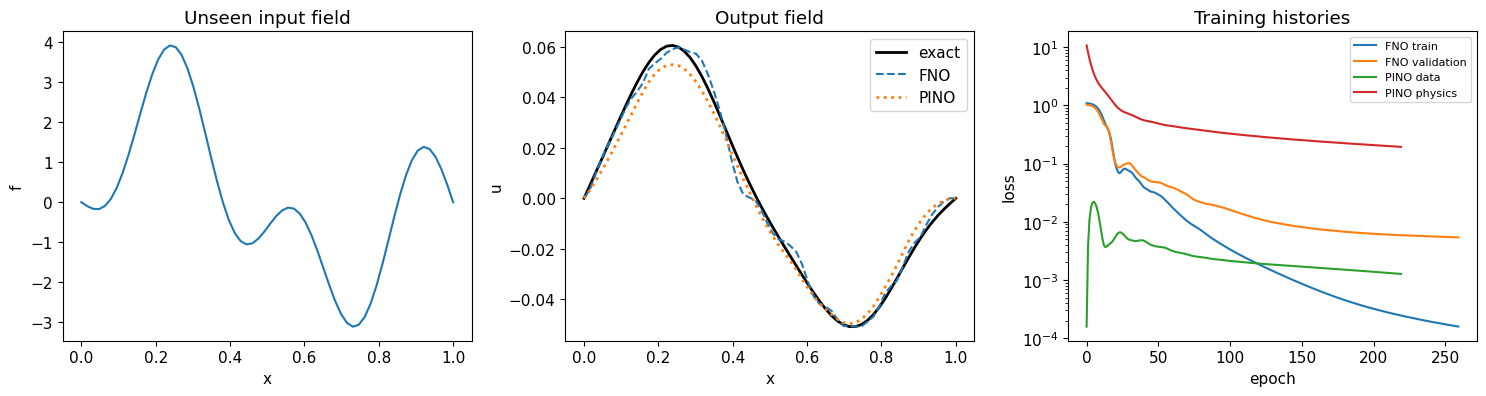

In [45]:
# Compare FNO and PINO on complete test problems not used in training.
fno_rel,fno_res,fno_up = operator_metrics(fno,op_test)
pino_rel,pino_res,pino_up = operator_metrics(pino,op_test)
print(f"FNO  mean relative solution error={fno_rel:.3e}, residual RMS={fno_res:.3e}")
print(f"PINO mean relative solution error={pino_rel:.3e}, residual RMS={pino_res:.3e}")

j=0
idx=op_test[j]
fig,ax=plt.subplots(1,3,figsize=(15,4.1))
ax[0].plot(x_op,f_fields[idx]); ax[0].set(title="Unseen input field",xlabel="x",ylabel="f")
ax[1].plot(x_op,u_fields[idx],"k",lw=2,label="exact")
ax[1].plot(x_op,fno_up[j],"--",label="FNO")
ax[1].plot(x_op,pino_up[j],":",lw=2,label="PINO")
ax[1].set(title="Output field",xlabel="x",ylabel="u"); ax[1].legend()
ax[2].semilogy(fno_hist["train"],label="FNO train")
ax[2].semilogy(fno_hist["val"],label="FNO validation")
ax[2].semilogy(pino_hist["data"],label="PINO data")
ax[2].semilogy(pino_hist["physics"],label="PINO physics")
ax[2].set(title="Training histories",xlabel="epoch",ylabel="loss"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

Physics information often reduces residual and can improve data efficiency, but PINO is not guaranteed to outperform FNO. Wrong equations, incomplete conditions, inaccurate derivatives, poor loss balance, failed optimization or out-of-family inputs can all degrade it.

## 33. FNO, PINN and PINO are different objects

| Method | Input | Output | Problems represented | Main training information |
|---|---|---|---|---|
| PINN | coordinate $x$ | value $u(x)$ | usually one | equation, conditions, optional data |
| FNO | field $f(\cdot)$ | field $u(\cdot)$ | a trained family | paired fields |
| PINO | field $f(\cdot)$ | field $u(\cdot)$ | a trained family | paired fields and/or equation residuals |

An FNO prediction outside the training distribution is extrapolation. Running at a different grid resolution may be possible architecturally, but accuracy is not guaranteed and must be tested.

# Part VII — Can PINO be used for an inverse problem?

## Freeze the forward PINO and estimate its input parameters

Yes. A safe pattern is:

1. train a forward PINO over a family;
2. freeze its weights;
3. describe an unknown input field with a few parameters;
4. change those parameters until the PINO output matches an observation;
5. verify the result using the original high-accuracy solver.

The next example recovers two coefficients in

$$
f_\alpha(x)=\alpha_1\sin(\pi x)+\alpha_2\sin(2\pi x)
$$

from observations of its solution. This is an operator-assisted inverse problem.

In [46]:
# Use the trained PINO as a fixed forward model.
#
# The PINO parameters were already learned during operator training.
# They are frozen here because this inverse problem should update only
# the unknown source coefficients, not the neural-operator weights.
for parameter in pino.parameters():
    parameter.requires_grad_(False)


# Define the true coefficients used to generate the synthetic observation.
#
# The unknown source field has the form
#
# f(x) = alpha_1 sin(pi x) + alpha_2 sin(2 pi x).
#
# These values are hidden from the inverse optimizer and are used only
# to generate and later check the synthetic result.
alpha_true = np.array(
    [0.8, -0.55],
    dtype=np.float32
)


# Construct the unknown source field on the operator grid.
f_unknown = (
    alpha_true[0] * np.sin(np.pi * x_op)
    + alpha_true[1] * np.sin(2.0 * np.pi * x_op)
)


# Construct the exact solution of
#
# -u''(x) = f(x),
# u(0) = u(1) = 0.
#
# Since
#
# -d^2/dx^2 [sin(n pi x)/(n pi)^2] = sin(n pi x),
#
# each sine component of the source has a known solution.
u_observed = (
    alpha_true[0]
    * np.sin(np.pi * x_op)
    / np.pi**2
    +
    alpha_true[1]
    * np.sin(2.0 * np.pi * x_op)
    / (2.0 * np.pi)**2
)


# Select a subset of interior grid points as sensors.
#
# The first and last three grid points are excluded so that the inverse
# calculation relies on interior solution measurements rather than
# directly using the boundary region.
#
# Every third remaining grid point is used as a sensor.
sensors = np.arange(
    3,
    nx_op - 3,
    3
)


# Define the two tunable inverse parameters.
#
# alpha[0] multiplies sin(pi x).
# alpha[1] multiplies sin(2 pi x).
#
# nn.Parameter tells PyTorch that these values should be updated
# by gradient-based optimization.
#
# The initial guess [0.1, 0.1] is intentionally different from
# the true values [0.8, -0.55].
alpha = nn.Parameter(
    torch.tensor(
        [0.1, 0.1],
        dtype=torch.float32,
        device=device
    )
)


# Create an optimizer that updates only alpha.
#
# The PINO parameters are not included in this optimizer.
opt_alpha = torch.optim.Adam(
    [alpha],
    lr=0.035
)


# Precompute the two basis functions on the operator grid.
#
# These tensors remain fixed during the inverse calculation.
sin1 = to_tensor(
    np.sin(np.pi * x_op)
)

sin2 = to_tensor(
    np.sin(2.0 * np.pi * x_op)
)


# Convert the observed solution to a PyTorch tensor.
u_observed_tensor = to_tensor(
    u_observed
)


# Store the inverse-problem loss after each epoch.
inverse_history = []


# Adjust alpha so that the PINO-predicted solution matches
# the observed solution at the sensor locations.
for epoch in range(500):

    # Remove gradients from the previous optimization step.
    opt_alpha.zero_grad()


    # Construct the current trial source field using the
    # present values of the two tunable coefficients.
    f_trial = (
        alpha[0] * sin1
        + alpha[1] * sin2
    )


    # Normalize the trial source using the same mean and standard
    # deviation used during PINO training.
    #
    # The PINO expects normalized input fields.
    f_trial_normalized = (
        f_trial - f_mean
    ) / f_std


    # Use the frozen PINO to predict the normalized solution field.
    #
    # [None, :] adds a batch dimension because the PINO expects
    # input with shape:
    #
    # batch size x number of grid points
    u_pred_normalized = pino(
        f_trial_normalized[None, :],
        grid_t
    )[0]


    # Convert the PINO output back to physical solution units.
    u_predicted = physical_u(
        u_pred_normalized
    )


    # Compare the predicted and observed solutions only at
    # the selected sensor locations.
    inverse_loss = torch.mean(
        (
            u_predicted[sensors]
            - u_observed_tensor[sensors]
        )**2
    )


    # Calculate the gradient of the sensor mismatch with respect
    # to alpha[0] and alpha[1].
    inverse_loss.backward()


    # Update the two source coefficients.
    opt_alpha.step()


    # Store the loss as an ordinary Python number.
    inverse_history.append(
        inverse_loss.item()
    )


# Display the known coefficients and the recovered coefficients.
print(
    "True input coefficients:    ",
    alpha_true
)

print(
    "PINO-inferred coefficients: ",
    alpha.detach().cpu().numpy()
)

True input coefficients:     [ 0.8  -0.55]
PINO-inferred coefficients:  [ 0.79165363 -0.5352339 ]


The recovered values may contain small surrogate bias because the PINO is approximate. A close output fit does not prove that a more general inverse is unique. Multiple profiles, independent anchors, uncertainty estimates and an original-solver verification are required for difficult constitutive inversion.

## The key idea is that the trained PINO is now kept fixed and used as a differentiable forward solver. Only the two unknown source coefficients are adjusted.



### What are the tunable parameters?

The source field is assumed to have the form

$$
f(x) = \alpha_1\sin(\pi x)
+
\alpha_2\sin(2\pi x).
$$

The two tunable parameters are therefore

$$
\alpha_1
\quad\text{and}\quad
\alpha_2.
$$

In the code, they are stored in

```python
alpha = nn.Parameter(
    torch.tensor([0.1, 0.1], device=device)
)
```

Thus,

```python
alpha[0]
```

represents $\alpha_1$, and

```python
alpha[1]
```

represents $\alpha_2$.

They control the amplitudes of the two spatial modes:

$$
\sin(\pi x)
$$

and

$$
\sin(2\pi x).
$$

The PINO weights are **not tunable in this inverse stage**. They are frozen by

```python
for parameter in pino.parameters():
    parameter.requires_grad_(False)
```

Therefore, the optimization problem is only

$$
\min_{\alpha_1,\alpha_2}
\frac{1}{N_s}
\sum_{j=1}^{N_s}
\left[
u_{\mathrm{PINO}}(x_j;\alpha_1,\alpha_2)-
u_{\mathrm{observed}}(x_j)
\right]^2.
$$

Here, $N_s$ is the number of sensors.

The computational chain is

$$
(\alpha_1,\alpha_2)
\rightarrow
f_{\mathrm{trial}}(x)
\rightarrow
u_{\mathrm{PINO}}(x)
\rightarrow
L_{\mathrm{inverse}}.
$$

Because every step is differentiable, PyTorch can calculate

$$
\frac{\partial L_{\mathrm{inverse}}}{\partial\alpha_1}
\qquad\text{and}\qquad
\frac{\partial L_{\mathrm{inverse}}}{\partial\alpha_2}.
$$

Adam then updates the coefficients until the predicted solution agrees with the sensor observations.

## Map the operator-assisted inverse idea to binary diffusion

A reusable diffusion PINO could represent

$$
\mathcal G_\theta:[c_0(x),\widetilde D_\alpha(c),T,t]\mapsto c(x,t).
$$

After forward training, freeze $\theta$, vary $\alpha$, and minimize profile mismatch plus constitutive anchors and priors. This is attractive when many couples or temperatures must be inverted. For only one experiment, the direct inverse PINN is usually simpler.

PINO accelerates repeated inversion; it does not remove non-uniqueness. A recovered law must remain inside the operator's training family and must be verified with the original solver and independent experiments.

## Before accepting any learned result, ask:

1. What mathematical object is represented: coefficients, one function, one field, or an operator?
2. Which quantities are trainable?
3. Which observations update parameters?
4. Which equations, boundaries, constitutive assumptions and anchors enter the loss?
5. Which information is reserved for validation and final testing?
6. Is the result interpolation or extrapolation?
7. Could different parameters produce nearly the same observable?
8. Has the result been checked using an independent solver or experiment?

**Network approximator ≠ Hall–Petch equation.  
PINN trial field ≠ governing equation.  
FNO architecture ≠ physics-informed training.  
PINO operator ≠ guaranteed identifiability.**

In [47]:
# Run basic checks for missing values, wrong shapes, and failed calculations.
assert np.isfinite(
    sigma0_ols
) and np.isfinite(
    k_ols
)

assert (
    u_pred_p.shape
    == u_exact_p.shape
)

assert np.all(
    np.isfinite(
        u_pred_p
    )
)

assert (
    concentration_prediction.shape
    == c_latest.shape
)

assert np.all(
    np.isfinite(
        diffusivity_prediction
    )
)

assert (
    fno_up.shape
    == pino_up.shape
    == (
        len(op_test),
        nx_op
    )
)

assert np.all(
    np.isfinite(
        alpha
        .detach()
        .cpu()
        .numpy()
    )
)

print(
    "All implementation checks passed."
)

print(
    "Forward PINN relative error:",
    np.linalg.norm(
        u_pred_p
        - u_exact_p
    )
    / np.linalg.norm(
        u_exact_p
    )
)

print(
    "Binary inverse profile RMSE:",
    rmse(
        c_latest,
        concentration_prediction
    )
)

print(
    "FNO/PINO test relative errors:",
    fno_rel,
    pino_rel
)


All implementation checks passed.
Forward PINN relative error: 0.0003520315970574072
Binary inverse profile RMSE: 0.00015640676526252283
FNO/PINO test relative errors: 0.08219062050629994 0.06298140770068296


In [ ]:
If this cell prints “All implementation checks passed,” the notebook has run in the intended order without NaNs, shape errors or broken links between calculations. Scientific acceptance still depends on uncertainty, identifiability, model discrepancy and independent validation.